## Часть 2. Работа с MLPClassifier

### <font color='#F5DEB3'> Подготовка обработанного датасета

In [13]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yaml

In [14]:
with open('C:/ML_Labs/LB3_ML_Yakushev/config/parameters.yaml', 'r', encoding='utf-8') as config_file:
    config = yaml.safe_load(config_file)

os.chdir(config['base']['root_project_dir'])

print(config)

{'base': {'random_state': 42, 'root_project_dir': 'C:/ML_Labs/LB3_ML_Yakushev'}, 'robot': {'dist_center': 0.125, 'wheel_angle': 30, 'wheel_radius': 0.04}, 'data': {'dataset_xlsx': 'data/Data_Set_(A+B).xlsx', 'dataset_processed': 'data/processed', 'dataset_test_xlsx': 'data/Data_Set_C.xlsx', 'target_column': 'Type', 'val_size': 0.2, 'type_space': 5}, 'MLP': {'model_params': {'cv_folds': 4}}}


In [15]:
processed_path = os.path.join(config['data']['dataset_processed'], 'Data_Set_AB_processed.xlsx')

V13 = pd.read_excel(processed_path)

In [16]:
target_col = [config['data']['target_column']]
feature_cols = [col for col in V13.columns if col not in target_col]

data_x = np.array(V13.drop(target_col, axis=1))
data_y = np.array(V13[target_col]).ravel()

### <font color='#F5DEB3'>Задание №1

1. Для выполнения практикума рекомендуется использовать полносвязную нейронную сеть прямого распространения – **MLPClassifier** из библиотеки машинного обучения sklearn.
2. Провести небольшую предварительную серию экспериментов с параметрами *“hidden_layer_sizes”*, *“activation”*, *“solver”* и *“max_iter”*, добиваясь наиболее близких между собой значений **критерия кросс-валидации** (перекрестного критерия ошибки) на обучающей выборке (Data Set_Train).
3. **Необходимо добиться** в режиме работы «на результат» как можно более высокой точности прогнозирования выходной величины в зависимости от гиперпараметров.

In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE, ADASYN

import ast

In [18]:
def train_models(
    data_x, data_y,
    hidden_options,
    activation_options,
    solver_options,
    max_iter_options,
    random_state,
    cv_folds
):
    results = []
    combo_id = 0

    for hls in hidden_options:
        for act in activation_options:
            for solv in solver_options:
                for max_it in max_iter_options:
                    combo_id += 1
                    mlp = MLPClassifier(
                        hidden_layer_sizes=hls,
                        activation=act,
                        solver=solv,
                        max_iter=max_it,
                        random_state=random_state,
                    )

                    # Accuracy
                    scores_acc = cross_val_score(mlp, data_x, data_y, cv=cv_folds, scoring='accuracy')
                    mean_acc = scores_acc.mean()
                    std_acc = scores_acc.std()

                    # F1-score
                    scores_f1 = cross_val_score(mlp, data_x, data_y, cv=cv_folds, scoring='f1')
                    mean_f1 = scores_f1.mean()
                    std_f1 = scores_f1.std()

                    # Вывод в консоль
                    print(f"Номер набора № {combo_id}. Гиперпараметры: "
                          f"hidden_layer_sizes={hls}, activation={act}, solver={solv}, max_iter={max_it} → "
                          f"Accuracy: {mean_acc:.3f} (±{std_acc:.3f}), "
                          f"F1-score: {mean_f1:.3f} (±{std_f1:.3f})")

                    results.append({
                        'combo_id': combo_id,
                        'hidden_layer_sizes': str(hls),
                        'activation': act,
                        'solver': solv,
                        'max_iter': max_it,
                        'cv_mean_accuracy': mean_acc,
                        'cv_std_accuracy': std_acc,
                        'cv_mean_f1': mean_f1,
                        'cv_std_f1': std_f1
                    })

    df_results = pd.DataFrame(results)
    return df_results


def plot_results(
        df_results, 
        output_path=None, 
        figsize=(14, 7), 
        dpi=600):
    """
    Строит столбчатую диаграмму сравнения Accuracy и F1-score
    и возвращает DataFrame, отсортированный по убыванию F1.
    """
    # Сортируем по убыванию F1
    df_sorted = df_results.sort_values('cv_mean_f1', ascending=False).reset_index(drop=True)

    x = np.arange(len(df_sorted))
    width = 0.35

    fig, ax = plt.subplots(figsize=figsize)

    # Столбцы Accuracy
    bars_acc = ax.bar(
        x - width/2, df_sorted['cv_mean_accuracy'], width,
        yerr=df_sorted['cv_std_accuracy'], capsize=4,
        label='Accuracy (CV mean ± std)', color='skyblue', alpha=0.8
    )

    # Столбцы F1-score
    bars_f1 = ax.bar(
        x + width/2, df_sorted['cv_mean_f1'], width,
        yerr=df_sorted['cv_std_f1'], capsize=4,
        label='F1-score (CV mean ± std)', color='lightcoral', alpha=0.8
    )

    ax.set_xlabel('Номер комбинации')
    ax.set_ylabel('Значение метрики (0–1)')
    ax.set_title('Сравнение кросс-валидационных Accuracy и F1-score\n(сортировка по убыванию F1)')
    ax.set_xticks(x)
    ax.set_xticklabels(df_sorted['combo_id'])
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Подписи значений на столбцах
    for bar in bars_acc:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    for bar in bars_f1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=dpi)

    plt.show()

    return df_sorted


def plot_model_by_combo_id(
    combo_id,
    df_results,
    data_x,
    data_y,
    random_state,
    n_show=None,
    output_path=None,   
    dpi=600             
):
    # 1. Поиск комбинации в таблице результатов
    selected_row = df_results[df_results['combo_id'] == combo_id]
    if selected_row.empty:
        print(f"Ошибка: комбинация с номером {combo_id} не найдена!")
        return
    row = selected_row.iloc[0]

    # 2. Извлечение гиперпараметров
    hls = ast.literal_eval(row['hidden_layer_sizes'])
    act = row['activation']
    solv = row['solver']
    max_it = row['max_iter']

    # 3. Вывод информации о модели
    print(f"Номер выборки - {combo_id}")
    print(f"Гиперпараметры - hidden_layer_sizes={hls}, activation='{act}', solver='{solv}', max_iter={max_it}")
    print(f"Accuracy = {row['cv_mean_accuracy']:.4f} ± {row['cv_std_accuracy']:.4f}, "
          f"F1-score = {row['cv_mean_f1']:.4f} ± {row['cv_std_f1']:.4f}")

    # 4. Создание и обучение модели на ВСЕХ данных
    mlp = MLPClassifier(
        hidden_layer_sizes=hls,
        activation=act,
        solver=solv,
        max_iter=max_it,
        random_state=random_state,
    )
    mlp.fit(data_x, data_y)

    # 5. Предсказание классов
    y_pred_class = mlp.predict(data_x)

    # 6. Визуализация
    if n_show is None:
        n_show = min(1000, len(data_y))
    indices = np.arange(n_show)

    plt.figure(figsize=(14, 6))
    plt.plot(indices, data_y[:n_show], label='Реальные метки (0/1)',
             color='blue', linewidth=2, alpha=0.8)
    plt.plot(indices, y_pred_class[:n_show], label='Предсказанный класс (0/1)',
             color='red', linewidth=2, alpha=0.8)
    plt.xlabel('Индекс примера')
    plt.ylabel('Класс (0 или 1)')
    plt.title(f'Сравнение реальных и предсказанных классов (комбинация №{combo_id}, первые {n_show} примеров)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Сохранение, если указан путь
    if output_path:
        plt.savefig(output_path, dpi=dpi, bbox_inches='tight')

    plt.show()

По мере изучения документации и информации на форумах и сайтах, были выделены следующие моменты:

**1. solver{‘lbfgs’, ‘sgd’, ‘adam’}.** 
- Решатель ‘lbfgs’ хорошо подходит для маленьких выборкаих и возможно даст наилучшие показатели качества по F1-scope.
- Решатель ‘sgd’ требует настройки гиперпараметров ’alpha’, ’learning_rate’ и др. гиперпараметры для точной работы. В отличие от него, решатель ‘adam’ имеет адаптивное масштабирование градиентов, автоматически подбирая скорость обучения для каждого веса. Это делает его устойчивым к выбору начального шага и позволяет надёжно обучаться без тонкой ручной настройки.

**2. activation{‘identity’, ‘logistic’, ‘tanh’, ‘relu’}.**
- ‘identity’ используется преимущественно в линейных моделях, поэтому он нам не подходит. 
- ‘logistic’ склонна к насыщению (при значениях близких к 0 или 1 останавливает обучение). Для многослойных сетей и малых наборах данных не рекомендуется к применению.
- ‘tanh’ по сравнению с ‘logistic’ сходимость обычно быстрее. Однако проблема насыщения сохраняется.
- ‘relu’ сходится быстро, подходит для малых выборок, более устойчив при работе с многослойными моделями. Практически безпроигрышный вариант на бумаге...

**3. max_iter**
Выбор маленького значения может привести к недообучению. Выбор большого значения может привести к переобучению. Идеальной формулы нет.

**4. hidden_layer_sizes - главная неоднозначность данной лабораторной**
- Задаёт архитектуру скрытых слоёв. Чем больше слоёв и нейронов, тем выше ёмкость модели и риск переобучения, особенно на малых выборках.
- При малых выборках не рекомендуется большое количество слоёв, модель с большей вероятностью переобучится.
- Число связей на порядок меньше выборки данных. В нашем случае это всего 18 связей, что выглядит сомнительно.

#### <font color='#F5DEB3'> 1.1 Тестирование с одним слоем

In [ ]:
hidden_opts = [(10,), (25,), (50,), (100,)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [10, 100, 1000]

In [32]:
df_res_without_1layer = train_models(
    data_x, data_y,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-package

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=adam, max_iter=20 → Accuracy: 0.483 (±0.121), F1-score: 0.354 (±0.155)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=adam, max_iter=100 → Accuracy: 0.722 (±0.065), F1-score: 0.139 (±0.155)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-pac

Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=adam, max_iter=500 → Accuracy: 0.767 (±0.025), F1-score: 0.139 (±0.155)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=lbfgs, max_iter=20 → Accuracy: 0.733 (±0.076), F1-score: 0.083 (±0.144)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=20).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_M

...

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=20).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=20).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_

Номер набора № 47. Гиперпараметры: hidden_layer_sizes=(100,), activation=tanh, solver=lbfgs, max_iter=100 → Accuracy: 0.784 (±0.047), F1-score: 0.369 (±0.260)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3

Номер набора № 48. Гиперпараметры: hidden_layer_sizes=(100,), activation=tanh, solver=lbfgs, max_iter=500 → Accuracy: 0.795 (±0.032), F1-score: 0.494 (±0.148)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


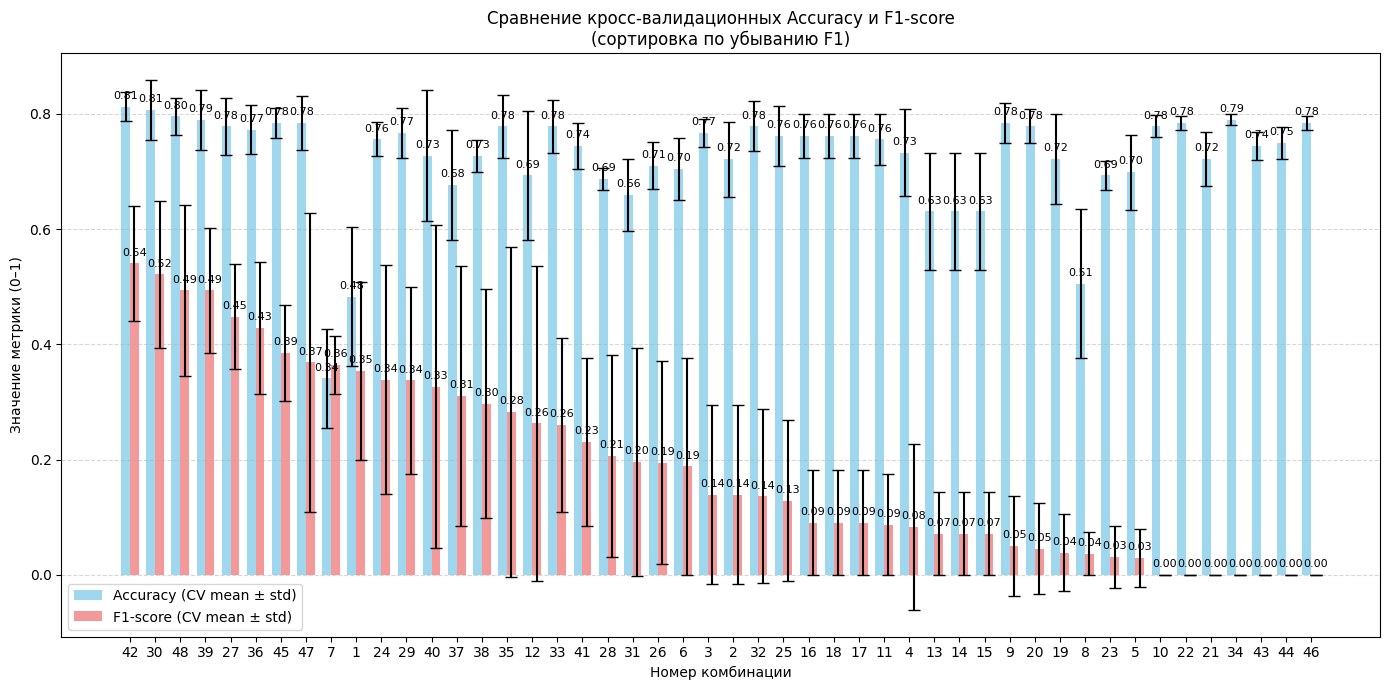

In [33]:
df_res_without_1layer = plot_results(df_res_without_1layer, 
                                     output_path='results/unchanged/hyperparameter_tuning_histograms_1layer.png')

df_res_without_1layer.to_csv('results/unchanged/hyperparameter_tuning_results_1layer.csv', index=False, encoding='utf-8')

In [34]:
display(df_res_without_1layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,42,"(100,)",relu,lbfgs,500,0.812500,0.024766,0.540534,0.099313
1,30,"(50,)",relu,lbfgs,500,0.806818,0.052075,0.521617,0.128023
2,48,"(100,)",tanh,lbfgs,500,0.795455,0.032141,0.493838,0.148355
3,39,"(100,)",relu,adam,500,0.789773,0.051764,0.493609,0.107941
4,27,"(50,)",relu,adam,500,0.778409,0.049206,0.448300,0.090705
5,36,"(50,)",tanh,lbfgs,500,0.772727,0.042519,0.428365,0.114164
6,45,"(100,)",tanh,adam,500,0.784091,0.025410,0.385417,0.082994
7,47,"(100,)",tanh,lbfgs,100,0.784091,0.046853,0.368650,0.259745
8,7,"(10,)",tanh,adam,20,0.340909,0.086543,0.364921,0.050486
9,1,"(10,)",relu,adam,20,0.482955,0.120663,0.353571,0.154977


Номер выборки - 42
Гиперпараметры - hidden_layer_sizes=(100,), activation='relu', solver='lbfgs', max_iter=500
Accuracy = 0.8125 ± 0.0248, F1-score = 0.5405 ± 0.0993


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


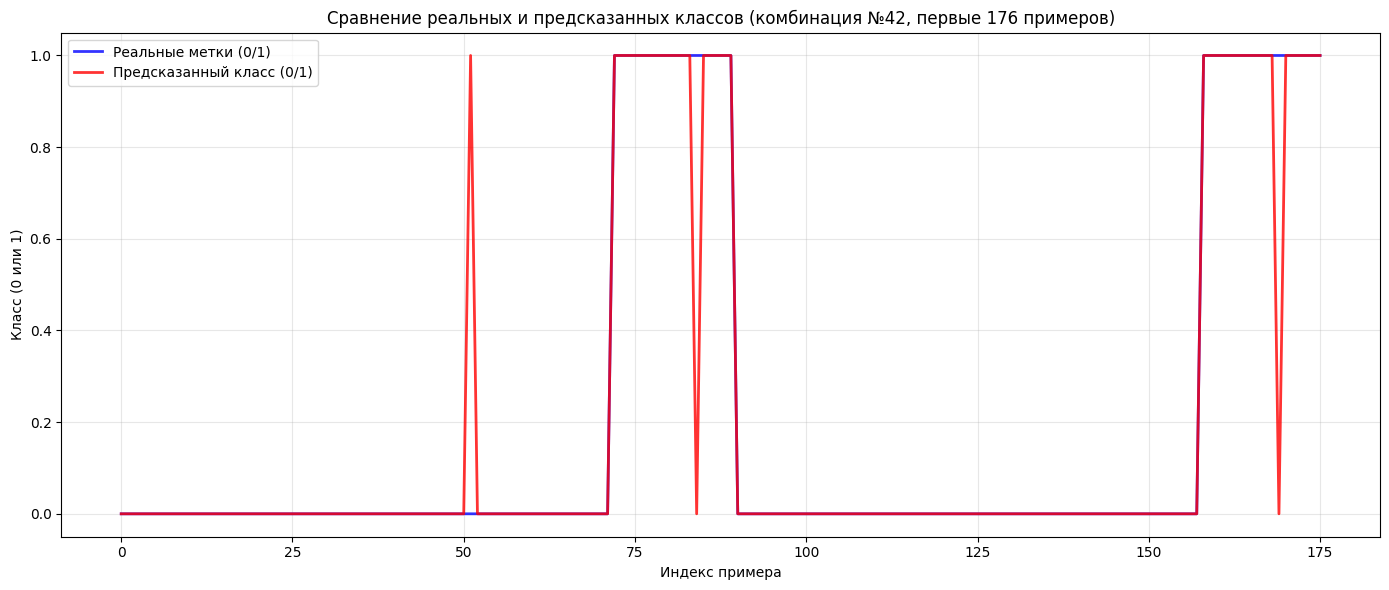

In [42]:
plot_model_by_combo_id(
    42,
    df_res_without_1layer,
    data_x,
    data_y,
    config['base']['random_state'],
    n_show=len(data_x),
    output_path='results/unchanged/layer1_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 1.2 Тестирование с двумя слоями

In [ ]:
hidden_opts = [(5, 5),  
               (20, 10),
               (50, 20), 
               (100, 50)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [20, 100, 1000]

In [44]:
df_res_without_2layer = train_models(
    data_x, data_y,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-package

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=adam, max_iter=20 → Accuracy: 0.239 (±0.025), F1-score: 0.323 (±0.034)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=adam, max_iter=100 → Accuracy: 0.284 (±0.025), F1-score: 0.328 (±0.039)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=adam, max_iter=500 → Accuracy: 0.710 (±0.071), F1-score: 0.100 (±0.173)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=lbfgs, max_iter=20 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=20).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=20).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_

...

Номер набора № 46. Гиперпараметры: hidden_layer_sizes=(100, 50), activation=tanh, solver=lbfgs, max_iter=20 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3

Номер набора № 47. Гиперпараметры: hidden_layer_sizes=(100, 50), activation=tanh, solver=lbfgs, max_iter=100 → Accuracy: 0.756 (±0.010), F1-score: 0.280 (±0.182)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Номер набора № 48. Гиперпараметры: hidden_layer_sizes=(100, 50), activation=tanh, solver=lbfgs, max_iter=500 → Accuracy: 0.739 (±0.110), F1-score: 0.428 (±0.230)


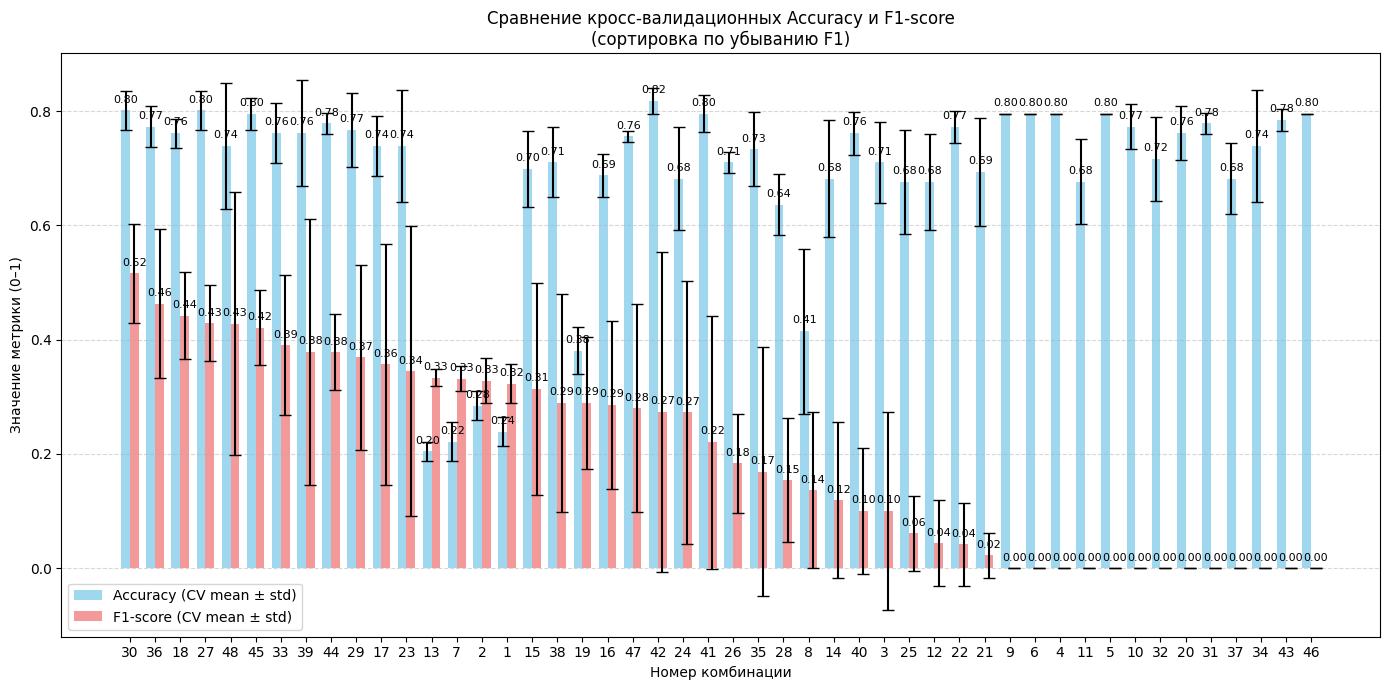

In [46]:
df_res_without_2layer = plot_results(df_res_without_2layer, 
                                     output_path='results/unchanged/hyperparameter_tuning_histograms_2layer.png')

df_res_without_2layer.to_csv('results/unchanged/hyperparameter_tuning_results_2layer.csv', index=False, encoding='utf-8')

In [47]:
display(df_res_without_2layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,30,"(50, 20)",relu,lbfgs,500,0.801136,0.033614,0.515831,0.086550
1,36,"(50, 20)",tanh,lbfgs,500,0.772727,0.035935,0.463127,0.130691
2,18,"(20, 10)",relu,lbfgs,500,0.761364,0.025410,0.441870,0.076556
3,27,"(50, 20)",relu,adam,500,0.801136,0.033614,0.428711,0.066165
4,48,"(100, 50)",tanh,lbfgs,500,0.738636,0.109587,0.427882,0.229801
5,45,"(100, 50)",tanh,adam,500,0.795455,0.027835,0.420833,0.065749
6,33,"(50, 20)",tanh,adam,500,0.761364,0.052075,0.390158,0.122829
7,39,"(100, 50)",relu,adam,500,0.761364,0.093015,0.378543,0.232388
8,44,"(100, 50)",tanh,adam,100,0.778409,0.018844,0.377778,0.066667
9,29,"(50, 20)",relu,lbfgs,100,0.767045,0.065031,0.368857,0.161380


Номер выборки - 30
Гиперпараметры - hidden_layer_sizes=(50, 20), activation='relu', solver='lbfgs', max_iter=500
Accuracy = 0.8011 ± 0.0336, F1-score = 0.5158 ± 0.0866


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


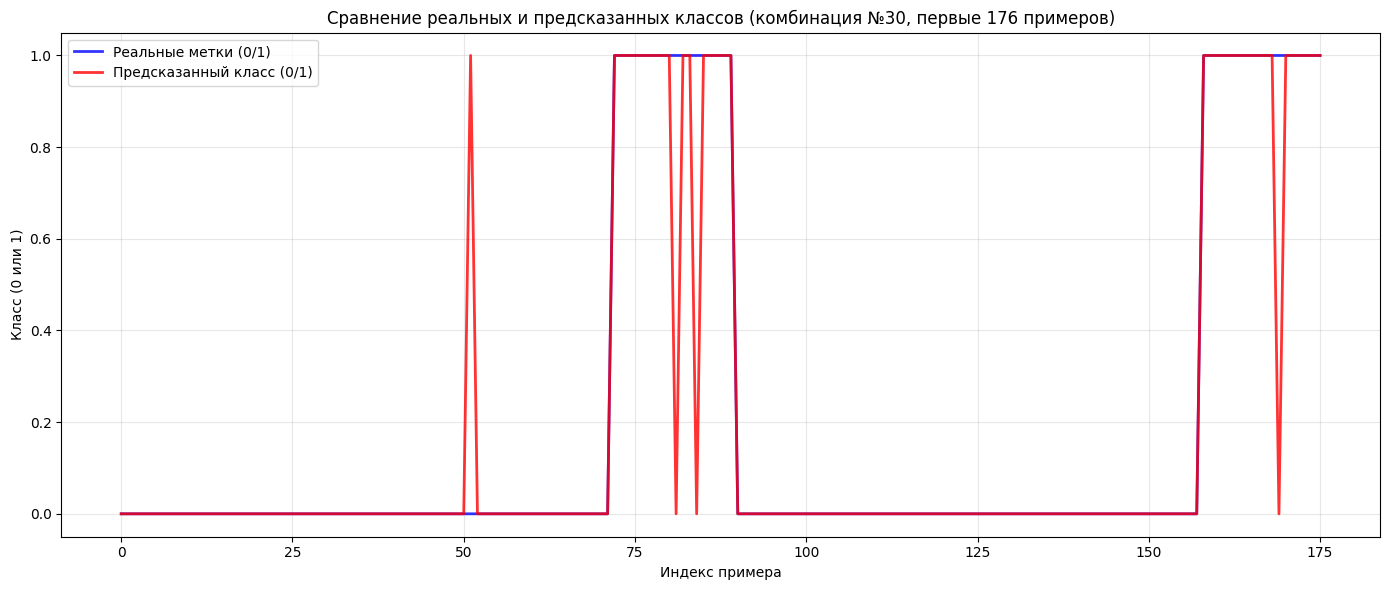

In [50]:
plot_model_by_combo_id(
    30,
    df_res_without_2layer,
    data_x,
    data_y,
    config['base']['random_state'],
    n_show=len(data_x),
    output_path='results/unchanged/layer2_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 1.3 Тестирование с тремя слоями

In [51]:
hidden_opts = [ (5, 5, 5),
                (10, 10, 10),
                (30, 30, 20),
                (50, 30, 20),
                (80, 50, 50)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [100, 1000]

In [52]:
df_res_without_3layer = train_models(
    data_x, data_y,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(5, 5, 5), activation=relu, solver=adam, max_iter=100 → Accuracy: 0.500 (±0.074), F1-score: 0.226 (±0.228)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(5, 5, 5), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.642 (±0.149), F1-score: 0.121 (±0.210)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3

Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(5, 5, 5), activation=relu, solver=lbfgs, max_iter=100 → Accuracy: 0.744 (±0.067), F1-score: 0.083 (±0.144)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(5, 5, 5), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.750 (±0.058), F1-score: 0.107 (±0.186)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-pac

...

Номер набора № 37. Гиперпараметры: hidden_layer_sizes=(80, 50, 50), activation=tanh, solver=adam, max_iter=100 → Accuracy: 0.773 (±0.028), F1-score: 0.429 (±0.045)
Номер набора № 38. Гиперпараметры: hidden_layer_sizes=(80, 50, 50), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.790 (±0.049), F1-score: 0.494 (±0.097)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3

Номер набора № 39. Гиперпараметры: hidden_layer_sizes=(80, 50, 50), activation=tanh, solver=lbfgs, max_iter=100 → Accuracy: 0.761 (±0.034), F1-score: 0.308 (±0.241)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Номер набора № 40. Гиперпараметры: hidden_layer_sizes=(80, 50, 50), activation=tanh, solver=lbfgs, max_iter=1000 → Accuracy: 0.750 (±0.070), F1-score: 0.417 (±0.179)


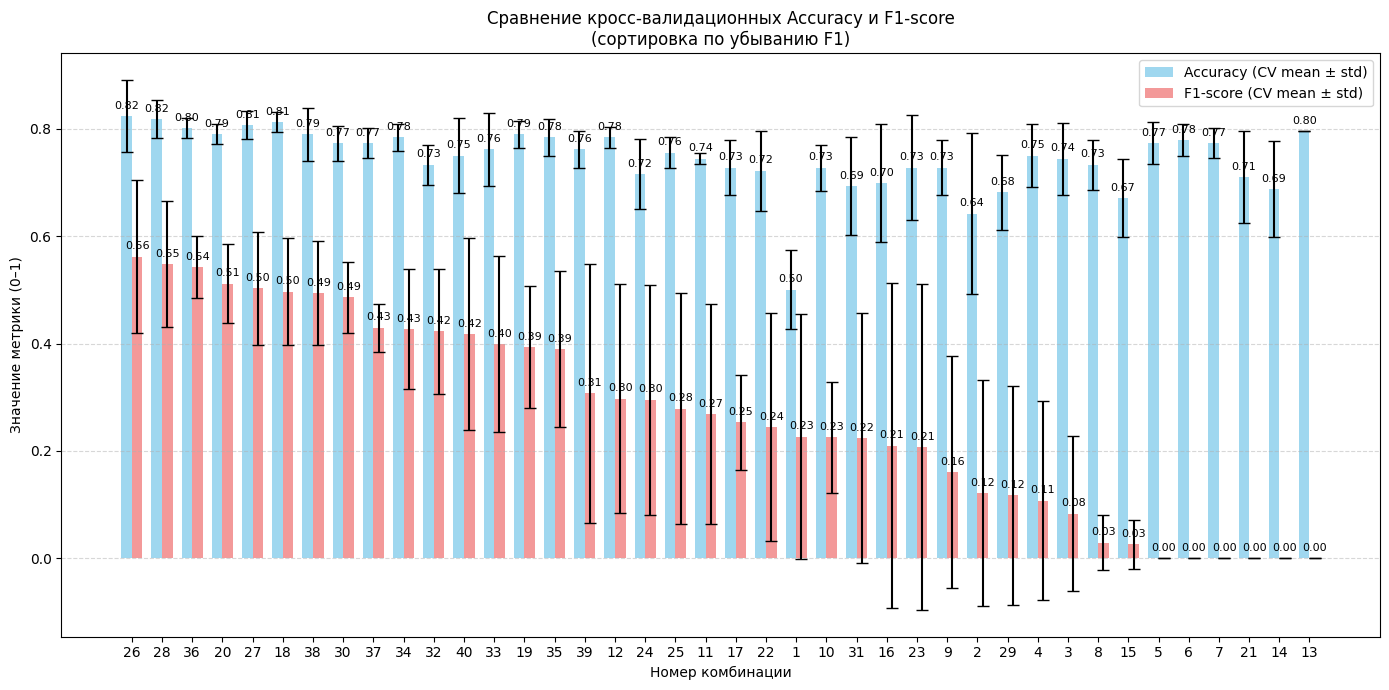

In [53]:
df_res_without_3layer = plot_results(df_res_without_3layer, 
                                     output_path='results/unchanged/hyperparameter_tuning_histograms_3layer.png')

df_res_without_3layer.to_csv('results/unchanged/hyperparameter_tuning_results_3layer.csv', index=False, encoding='utf-8')

In [54]:
display(df_res_without_3layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,26,"(50, 30, 20)",relu,adam,1000,0.823864,0.066988,0.561842,0.142853
1,28,"(50, 30, 20)",relu,lbfgs,1000,0.818182,0.035935,0.547388,0.117389
2,36,"(80, 50, 50)",relu,lbfgs,1000,0.801136,0.018844,0.542647,0.058288
3,20,"(30, 30, 20)",relu,lbfgs,1000,0.789773,0.018844,0.511364,0.073399
4,27,"(50, 30, 20)",relu,lbfgs,100,0.806818,0.025410,0.503064,0.105155
5,18,"(30, 30, 20)",relu,adam,1000,0.812500,0.018844,0.496784,0.100447
6,38,"(80, 50, 50)",tanh,adam,1000,0.789773,0.049206,0.494048,0.097263
7,30,"(50, 30, 20)",tanh,adam,1000,0.772727,0.032141,0.486364,0.066135
8,37,"(80, 50, 50)",tanh,adam,100,0.772727,0.027835,0.429276,0.044953
9,34,"(80, 50, 50)",relu,adam,1000,0.784091,0.025410,0.426269,0.111748


Номер выборки - 36
Гиперпараметры - hidden_layer_sizes=(80, 50, 50), activation='relu', solver='lbfgs', max_iter=1000
Accuracy = 0.8011 ± 0.0188, F1-score = 0.5426 ± 0.0583


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


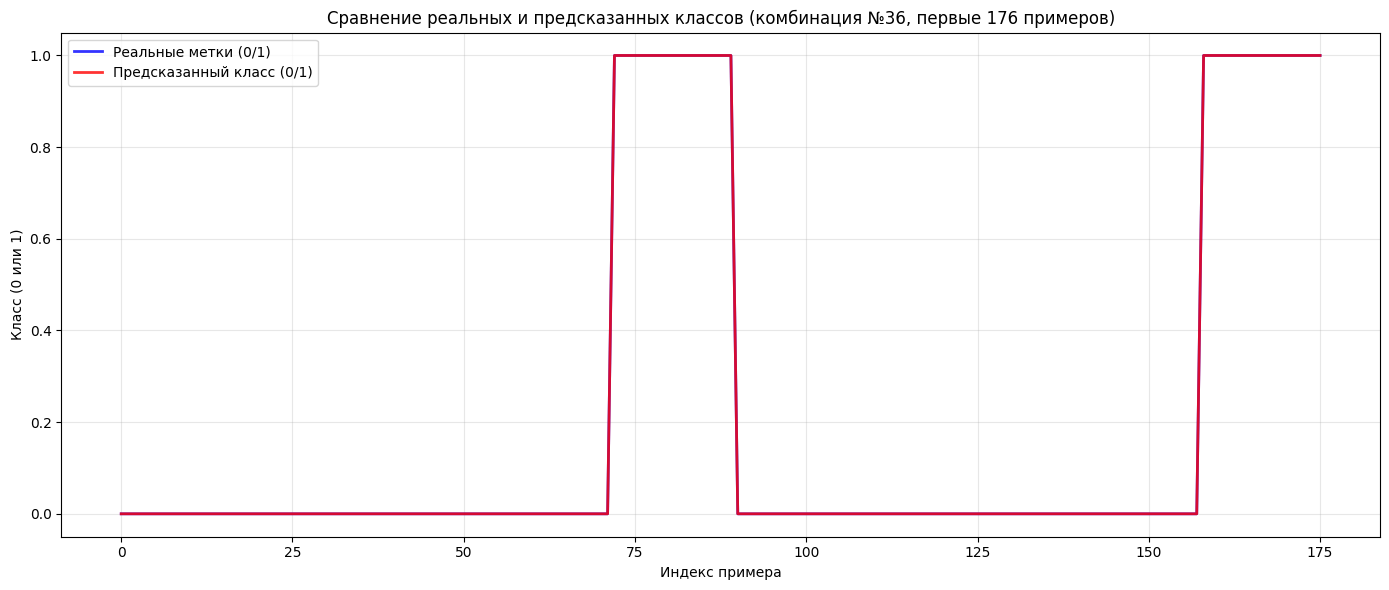

In [61]:
plot_model_by_combo_id(
    36,
    df_res_without_3layer,
    data_x,
    data_y,
    config['base']['random_state'],
    n_show=len(data_x),
    output_path='results/unchanged/layer3_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 1.4 Подведение итогов

* **Лучший результат 1-го слоя:**
Гиперпараметры - hidden_layer_sizes=(50,), activation='relu', solver='lbfgs', max_iter=5000.
Accuracy = 0.8011 ± 0.0436, F1-score = 0.5470 ± 0.1046.

* **Лучший результат 2-го слоя:**
*Гиперпараметры - hidden_layer_sizes=(50, 20), activation='relu', solver='lbfgs', max_iter=1000.*
*Accuracy = 0.8068 ± 0.0197, F1-score = 0.5253 ± 0.0255.*

* **Лучший результат 3-го слоя:**
Гиперпараметры - hidden_layer_sizes=(100, 50, 10), activation='tanh', solver='lbfgs', max_iter=5000.
Accuracy = 0.7500 ± 0.0359, F1-score = 0.4063 ± 0.0233.

Все 3 набора гиперпараметров практически 100% предсказали обучающую выборку. Стоит отметить, что у однослойной сети малая устойчивость по F1-scope, что критично.       
**Лучший результат показала 2-слойная нейронная сеть**.     
**В целом, результаты предварительного анализа примерно совпали с результатами.** 

### <font color='#F5DEB3'>Задание №2

5. Провести  эксперимент  по  п.3  с  сортированными  данными.  Для  этого,  можно  скопировать 
предыдущий  код  в  новые  ячейки  блокнота  (ниже)  и  поменять  загрузку  датасета  в  функции 
read_excel на ‘Data Set_Train (Sort).xlsx’. 
 
6. Зафиксировать лучший полученный результат по п.5 –  выставить в блокноте результат лучшего 
найденного результата обучения  (график и значения критериев понадобятся для отчёта).

In [19]:
import numpy as np
import pandas as pd

def create_pattern_sequence(df, target_col, pattern=(4, 1), random_state=42):
    rng = np.random.default_rng(random_state)
    
    idx0 = df[df[target_col] == 0].index.values
    idx1 = df[df[target_col] == 1].index.values
    rng.shuffle(idx0)
    rng.shuffle(idx1)
    
    n_blocks = min(len(idx0) // pattern[0], len(idx1) // pattern[1])
    
    # формируем блоки
    blocks = []
    for i in range(n_blocks):
        block = np.concatenate([
            idx0[i*pattern[0] : (i+1)*pattern[0]],
            idx1[i*pattern[1] : (i+1)*pattern[1]]
        ])
        blocks.append(block)
    
    # оставшиеся элементы (обычно это дополнительные нули)
    leftover0 = idx0[n_blocks*pattern[0]:]
    leftover1 = idx1[n_blocks*pattern[1]:]
    leftover = np.concatenate([leftover0, leftover1])
    if len(leftover) > 0:
        blocks.append(leftover)
    
    # объединяем все блоки в один список индексов
    new_order = np.concatenate(blocks)
    return df.loc[new_order].reset_index(drop=True)

In [20]:
target_col = config['data']['target_column']
data_y = V13[target_col].values

V13_sorted = create_pattern_sequence(V13, target_col, pattern=(4, 1))
data_x_sorted = V13_sorted.drop(target_col, axis=1).values
data_y_sorted = V13_sorted[target_col].values

V13_sorted.to_excel('data/processed/Data_Set_sorted.xlsx', index=False)

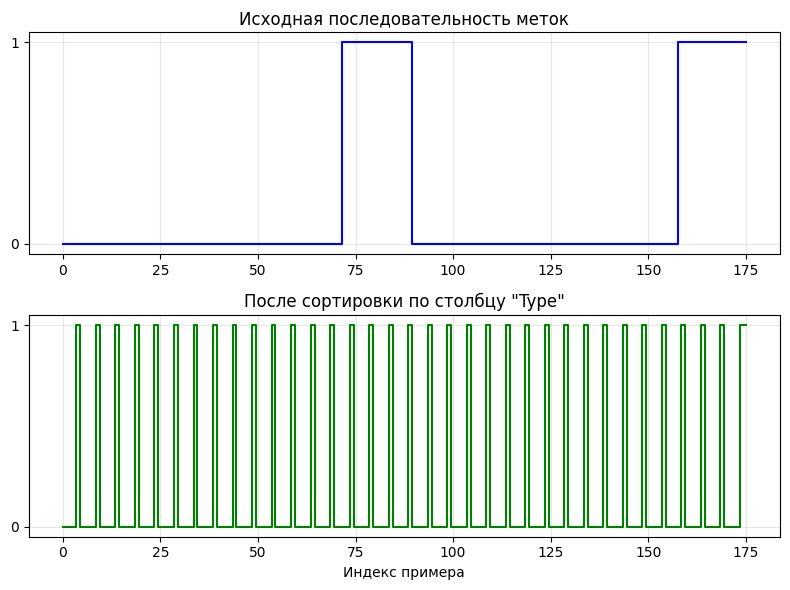

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].step(np.arange(len(data_y)), data_y, where='mid', color='blue')
axes[0].set_title('Исходная последовательность меток')
axes[0].set_yticks([0, 1])
axes[0].grid(True, alpha=0.3)

axes[1].step(np.arange(len(data_y_sorted)), data_y_sorted, where='mid', color='green')
axes[1].set_title('После сортировки по столбцу "Type"')
axes[1].set_xlabel('Индекс примера')
axes[1].set_yticks([0, 1])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### <font color='#F5DEB3'> 2.1 Тестирование с одним слоем

In [517]:
hidden_opts = [(10,), (20,), (50,), (100,)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [1000, 5000]

In [518]:
df_res_sorted_1layer = train_models(
    data_x_sorted, data_y_sorted,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.767 (±0.052), F1-score: 0.153 (±0.105)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.767 (±0.052), F1-score: 0.153 (±0.105)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.750 (±0.051), F1-score: 0.198 (±0.142)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.750 (±0.051), F1-score: 0.198 (±0.142)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(10,), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.790 (±0.010), F1-score: 0.045 (±0.079)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(10,), activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.790 (±0.010), F1-score: 0.045 (±0.079)
Номер набора № 7. Гиперпараметры: hidden_layer_sizes=(10

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site

Номер набора № 17. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.812 (±0.025), F1-score: 0.516 (±0.094)
Номер набора № 18. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.807 (±0.025), F1-score: 0.508 (±0.091)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Номер набора № 19. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.818 (±0.085), F1-score: 0.460 (±0.276)


...

Номер набора № 28. Гиперпараметры: hidden_layer_sizes=(100,), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.807 (±0.038), F1-score: 0.437 (±0.255)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Номер набора № 29. Гиперпараметры: hidden_layer_sizes=(100,), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.795 (±0.028), F1-score: 0.483 (±0.081)
Номер набора № 30. Гиперпараметры: hidden_layer_sizes=(100,), activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.795 (±0.028), F1-score: 0.483 (±0.081)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs

Номер набора № 31. Гиперпараметры: hidden_layer_sizes=(100,), activation=tanh, solver=lbfgs, max_iter=1000 → Accuracy: 0.795 (±0.043), F1-score: 0.473 (±0.042)
Номер набора № 32. Гиперпараметры: hidden_layer_sizes=(100,), activation=tanh, solver=lbfgs, max_iter=5000 → Accuracy: 0.790 (±0.034), F1-score: 0.481 (±0.049)


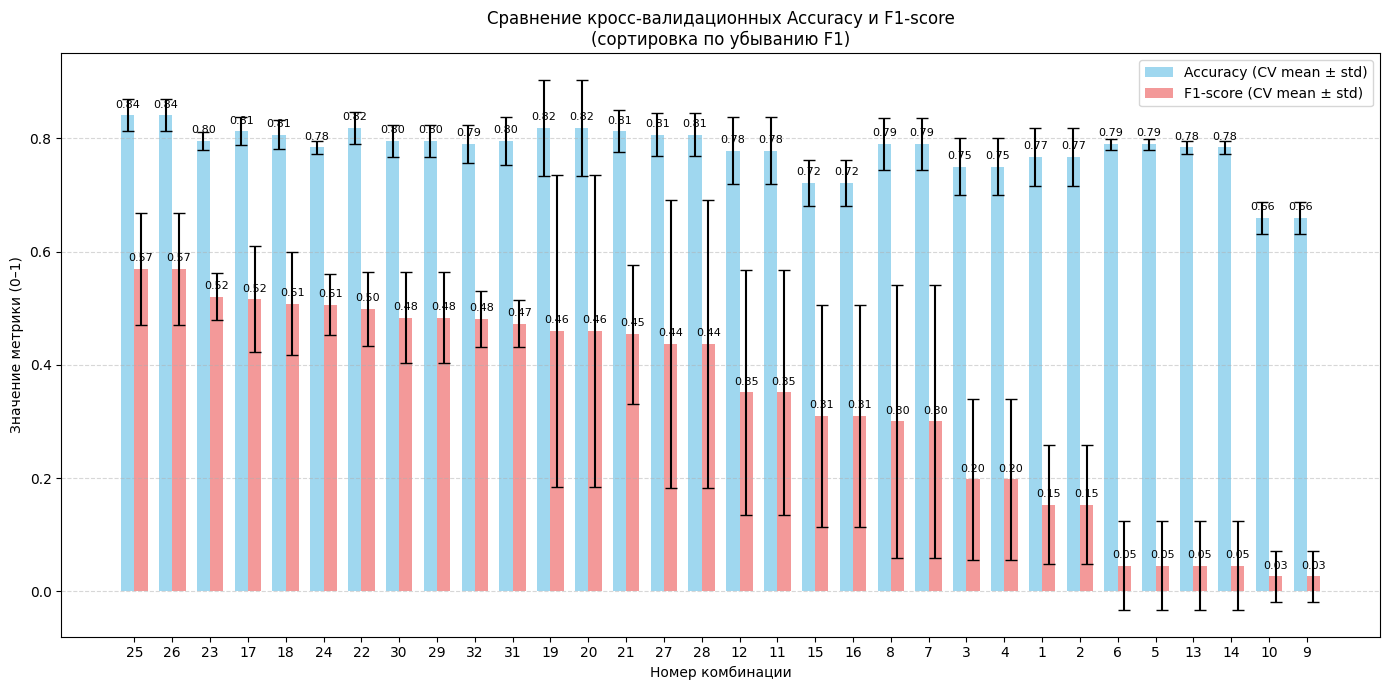

In [519]:
df_res_sorted_1layer = plot_results(df_res_sorted_1layer, 
                                     output_path='results/sorted/hyperparameter_tuning_histograms_1layer.png')

df_res_sorted_1layer.to_csv('results/sorted/hyperparameter_tuning_results_1layer.csv', index=False, encoding='utf-8')

In [520]:
display(df_res_sorted_1layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,25,"(100,)",relu,adam,1000,0.840909,0.027835,0.569561,0.098750
1,26,"(100,)",relu,adam,5000,0.840909,0.027835,0.569561,0.098750
2,23,"(50,)",tanh,lbfgs,1000,0.795455,0.016071,0.520059,0.041511
3,17,"(50,)",relu,adam,1000,0.812500,0.024766,0.515534,0.093621
4,18,"(50,)",relu,adam,5000,0.806818,0.025410,0.508224,0.091324
5,24,"(50,)",tanh,lbfgs,5000,0.784091,0.011364,0.506170,0.053470
6,22,"(50,)",tanh,adam,5000,0.818182,0.027835,0.498646,0.065341
7,30,"(100,)",tanh,adam,5000,0.795455,0.027835,0.483499,0.080778
8,29,"(100,)",tanh,adam,1000,0.795455,0.027835,0.483499,0.080778
9,32,"(100,)",tanh,lbfgs,5000,0.789773,0.033614,0.481287,0.049300


Номер выборки - 23
Гиперпараметры - hidden_layer_sizes=(50,), activation='tanh', solver='lbfgs', max_iter=1000
Accuracy = 0.7955 ± 0.0161, F1-score = 0.5201 ± 0.0415


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


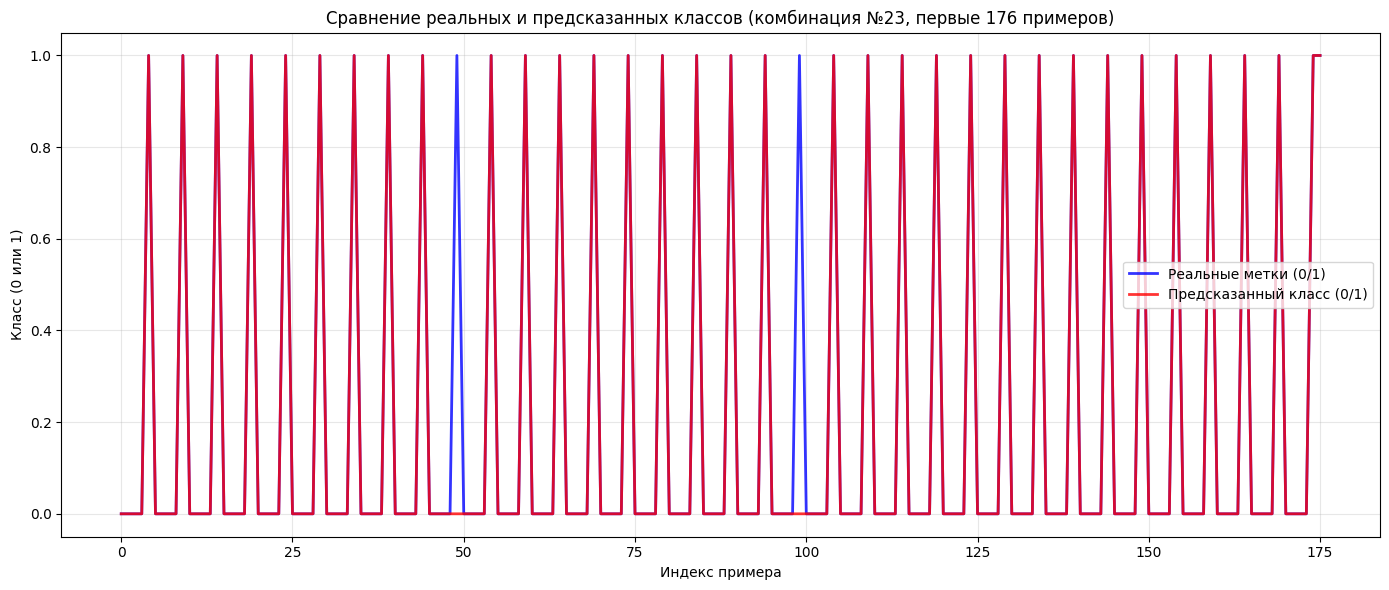

In [521]:
plot_model_by_combo_id(
    23,
    df_res_sorted_1layer,
    data_x_sorted,
    data_y_sorted,
    config['base']['random_state'],
    n_show=len(data_x_sorted),
    output_path='results/sorted/layer1_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 2.2 Тестирование с двумя слоями

In [522]:
hidden_opts = [(5, 5), 
               (10, 10), 
               (20, 10),
               (50, 20), 
               (100, 50)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [2500, 5000]

In [523]:
df_res_sorted_2layer = train_models(
    data_x_sorted, data_y_sorted,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=adam, max_iter=2500 → Accuracy: 0.682 (±0.132), F1-score: 0.067 (±0.115)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.682 (±0.132), F1-score: 0.067 (±0.115)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=lbfgs, max_iter=2500 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 17 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 17 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 17 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as 

Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=tanh, solver=adam, max_iter=2500 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 7. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=tanh, solver=lbfgs, max_iter=2500 → Accuracy: 0.750 (±0.056), F1-score: 0.205 (±0.133)
Номер набора № 8. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=tanh, solver=lbfgs, max_iter=5000 → Accuracy: 0.750 (±0.056), F1-score: 0.205 (±0.133)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2500) reached and the optimization hasn't converged yet.
  warnings.warn(


Номер набора № 9. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=relu, solver=adam, max_iter=2500 → Accuracy: 0.812 (±0.010), F1-score: 0.476 (±0.087)
Номер набора № 10. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.807 (±0.020), F1-score: 0.470 (±0.081)
Номер набора № 11. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=relu, solver=lbfgs, max_iter=2500 → Accuracy: 0.784 (±0.011), F1-score: 0.390 (±0.085)
Номер набора № 12. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.784 (±0.011), F1-score: 0.390 (±0.085)
Номер набора № 13. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=tanh, solver=adam, max_iter=2500 → Accuracy: 0.778 (±0.010), F1-score: 0.042 (±0.072)
Номер набора № 14. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.778 (±0.010), F1-score: 0.042 (±0.072)
Номер набора № 15. Гиперпараметры

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as sho

Номер набора № 35. Гиперпараметры: hidden_layer_sizes=(100, 50), activation=relu, solver=lbfgs, max_iter=2500 → Accuracy: 0.795 (±0.000), F1-score: 0.132 (±0.228)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as sho

Номер набора № 36. Гиперпараметры: hidden_layer_sizes=(100, 50), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.795 (±0.000), F1-score: 0.132 (±0.228)
Номер набора № 37. Гиперпараметры: hidden_layer_sizes=(100, 50), activation=tanh, solver=adam, max_iter=2500 → Accuracy: 0.835 (±0.030), F1-score: 0.566 (±0.082)
Номер набора № 38. Гиперпараметры: hidden_layer_sizes=(100, 50), activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.835 (±0.030), F1-score: 0.566 (±0.082)
Номер набора № 39. Гиперпараметры: hidden_layer_sizes=(100, 50), activation=tanh, solver=lbfgs, max_iter=2500 → Accuracy: 0.807 (±0.041), F1-score: 0.511 (±0.111)
Номер набора № 40. Гиперпараметры: hidden_layer_sizes=(100, 50), activation=tanh, solver=lbfgs, max_iter=5000 → Accuracy: 0.807 (±0.041), F1-score: 0.511 (±0.111)


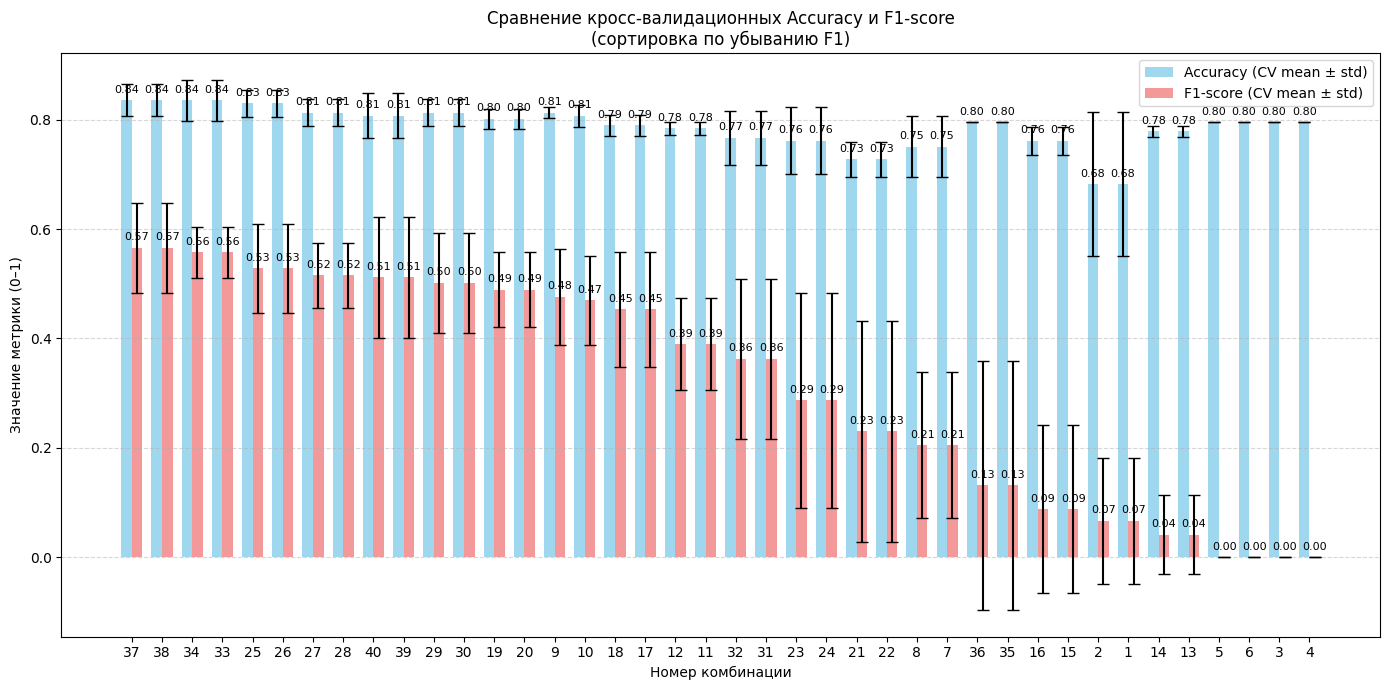

In [524]:
df_res_sorted_2layer = plot_results(df_res_sorted_2layer, 
                                     output_path='results/sorted/hyperparameter_tuning_histograms_2layer.png')

df_res_sorted_2layer.to_csv('results/sorted/hyperparameter_tuning_results_2layer.csv', index=False, encoding='utf-8')

In [525]:
display(df_res_sorted_2layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,37,"(100, 50)",tanh,adam,2500,0.835227,0.029524,0.565564,0.082270
1,38,"(100, 50)",tanh,adam,5000,0.835227,0.029524,0.565564,0.082270
2,34,"(100, 50)",relu,adam,5000,0.835227,0.037258,0.557440,0.046477
3,33,"(100, 50)",relu,adam,2500,0.835227,0.037258,0.557440,0.046477
4,25,"(50, 20)",relu,adam,2500,0.829545,0.025410,0.528099,0.080962
5,26,"(50, 20)",relu,adam,5000,0.829545,0.025410,0.528099,0.080962
6,27,"(50, 20)",relu,lbfgs,2500,0.812500,0.024766,0.515565,0.059128
7,28,"(50, 20)",relu,lbfgs,5000,0.812500,0.024766,0.515565,0.059128
8,40,"(100, 50)",tanh,lbfgs,5000,0.806818,0.040972,0.511481,0.111321
9,39,"(100, 50)",tanh,lbfgs,2500,0.806818,0.040972,0.511481,0.111321


Номер выборки - 34
Гиперпараметры - hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=5000
Accuracy = 0.8352 ± 0.0373, F1-score = 0.5574 ± 0.0465


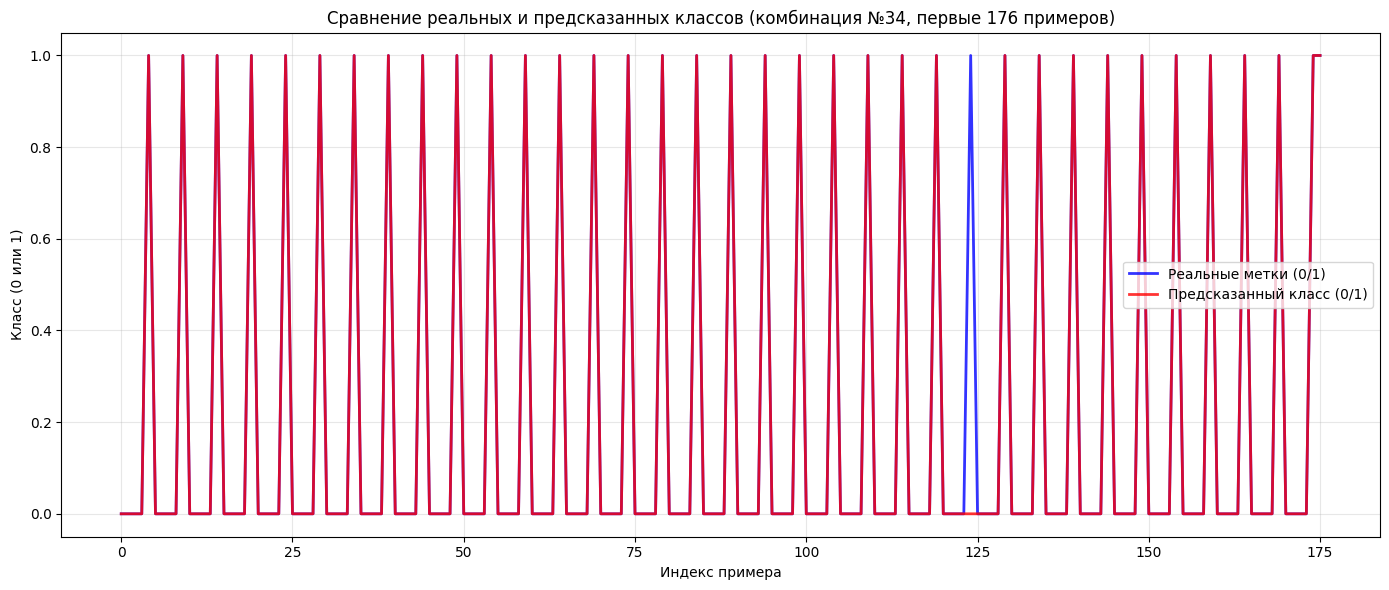

In [526]:
plot_model_by_combo_id(
    34,
    df_res_sorted_2layer,
    data_x_sorted,
    data_y_sorted,
    config['base']['random_state'],
    n_show=len(data_x_sorted),
    output_path='results/sorted/layer2_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 2.3 Тестирование с тремя слоями

In [527]:
hidden_opts = [ (5, 5, 5),
                (10, 10, 10),
                (50, 20, 10),
                (100, 50, 10),
                (100, 100, 50)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [5000]

In [528]:
df_res_sorted_3layer = train_models(
    data_x_sorted, data_y_sorted,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(5, 5, 5), activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.705 (±0.119), F1-score: 0.105 (±0.070)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(5, 5, 5), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.790 (±0.019), F1-score: 0.284 (±0.127)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(5, 5, 5), activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.790 (±0.010), F1-score: 0.045 (±0.079)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(5, 5, 5), activation=tanh, solver=lbfgs, max_iter=5000 → Accuracy: 0.784 (±0.011), F1-score: 0.129 (±0.075)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.784 (±0.047), F1-score: 0.429 (±0.045)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.824 (±0.049), F1-score: 0.558 (±0.089)
Номер набора № 7. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.778 (±0.019), F1-score: 0.042 (±0.072)
Номер набора № 8. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=tanh, solver=lbfgs, max_iter=5000 → Accuracy: 0.767 (±0.044), F1-score: 0.236 (±0.203)
Номер набора № 9. Гиперпараметры: hidden_layer_sizes=(50, 20, 10), activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.847 (±0.034), F1-score: 0.590 (±0.118)
Номер набора № 1

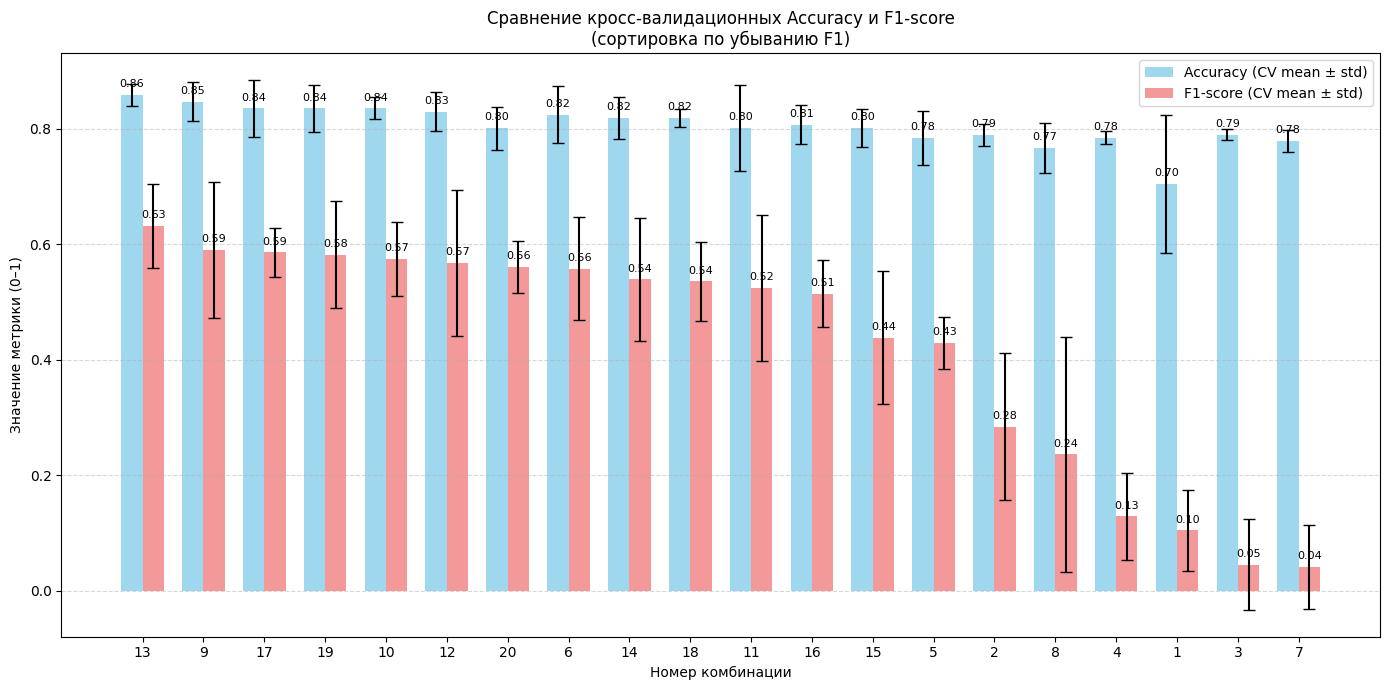

In [529]:
df_res_sorted_3layer = plot_results(df_res_sorted_3layer, 
                                     output_path='results/sorted/hyperparameter_tuning_histograms_3layer.png')

df_res_sorted_3layer.to_csv('results/sorted/hyperparameter_tuning_results_3layer.csv', index=False, encoding='utf-8')

In [530]:
display(df_res_sorted_3layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,13,"(100, 50, 10)",relu,adam,5000,0.857955,0.018844,0.631689,0.072069
1,9,"(50, 20, 10)",relu,adam,5000,0.846591,0.033614,0.590196,0.117696
2,17,"(100, 100, 50)",relu,adam,5000,0.835227,0.049206,0.585792,0.042964
3,19,"(100, 100, 50)",tanh,adam,5000,0.835227,0.040576,0.581699,0.092663
4,10,"(50, 20, 10)",relu,lbfgs,5000,0.835227,0.018844,0.575000,0.064010
5,12,"(50, 20, 10)",tanh,lbfgs,5000,0.829545,0.034091,0.567663,0.126965
6,20,"(100, 100, 50)",tanh,lbfgs,5000,0.801136,0.037258,0.560471,0.045184
7,6,"(10, 10, 10)",relu,lbfgs,5000,0.823864,0.049206,0.557878,0.088717
8,14,"(100, 50, 10)",relu,lbfgs,5000,0.818182,0.035935,0.539054,0.106981
9,18,"(100, 100, 50)",relu,lbfgs,5000,0.818182,0.016071,0.535781,0.067932


Номер выборки - 17
Гиперпараметры - hidden_layer_sizes=(100, 100, 50), activation='relu', solver='adam', max_iter=5000
Accuracy = 0.8352 ± 0.0492, F1-score = 0.5858 ± 0.0430


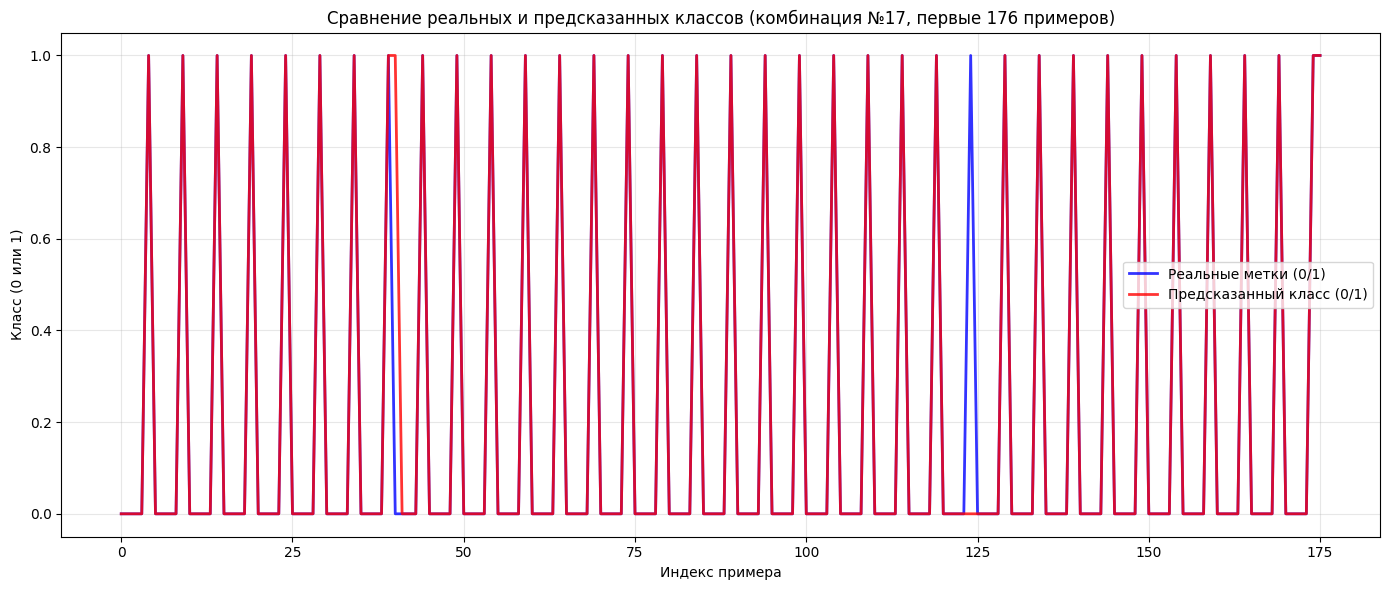

In [531]:
plot_model_by_combo_id(
    17,
    df_res_sorted_3layer,
    data_x_sorted,
    data_y_sorted,
    config['base']['random_state'],
    n_show=len(data_x),
    output_path='results/sorted/layer3_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 2.4 Подведение итогов

* **Лучший результат 1-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(50,), activation='relu', solver='lbfgs', max_iter=5000.
Accuracy = 0.8011 ± 0.0436, F1-score = 0.5470 ± 0.1046.

* **Лучший результат 1-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(50,), activation='tanh', solver='lbfgs', max_iter=1000.    
Accuracy = 0.7955 ± 0.0161, F1-score = 0.5201 ± 0.0415.

* **Лучший результат 2-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(50, 20), activation='relu', solver='lbfgs', max_iter=1000.
Accuracy = 0.8068 ± 0.0197, F1-score = 0.5253 ± 0.0255.

* **Лучший результат 2-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=5000.     
Accuracy = 0.8352 ± 0.0373, F1-score = 0.5574 ± 0.0465.

* **Лучший результат 3-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(100, 50, 10), activation='tanh', solver='lbfgs', max_iter=5000.
Accuracy = 0.7500 ± 0.0359, F1-score = 0.4063 ± 0.0233.

* **Лучший результат 3-го слоя (Sorted):**
*Гиперпараметры - hidden_layer_sizes=(100, 100, 50), activation='relu', solver='adam', max_iter=5000.*   
*Accuracy = 0.8352 ± 0.0492, F1-score = 0.5858 ± 0.0430.*

**Лучший результат: 3 слоя с сортировкой датасета**.

### <font color='#F5DEB3'>Задание №3

7. Поскольку все датчики имеют различные диапазоны измерений, то логично их привести к одному 
диапазону (например, [0,1]) для того, чтобы их вклад в функцию нейрона был одинаковым. Для 
нормализации  данных  можно  воспользоваться  функцией  MinMaxScaler  библиотеки  Sklearn 
(https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html).
 
8. Провести эксперимент по п.3 с нормализованными данными. При этом, в качестве выборки данных, 
которая загружается в переменную Data из Excel, необходимо выбрать ту (с сортировкой или без 
сортировки),  на  которой  в  предыдущих  экспериментах  результат  получился  лучше  по  кросс-
валидации и критерию F1. 
 
9.  Зафиксировать лучший полученный результат по п.8 –  выставить в блокноте результат лучшего 
найденного результата обучения (график и значения критериев понадобятся для отчёта).

In [7]:
scaler = MinMaxScaler()

data_x_scaled = scaler.fit_transform(data_x)

#### <font color='#F5DEB3'> 3.1 Тестирование с одним слоем

In [533]:
hidden_opts = [(10,), (20,), (50,), (100,)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [1000, 5000]

In [534]:
df_res_scaled_1layer = train_models(
    data_x_scaled, data_y,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.801 (±0.034), F1-score: 0.464 (±0.121)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.801 (±0.034), F1-score: 0.464 (±0.121)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(10,), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(10,), activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.795 (±0.000), F1-score: 0.045 (±0.079)
Номер набора № 7. Гиперпараметры: hidden_layer_sizes=(10,), activation=tanh, solver=lbfgs, max_iter=1000 → Accuracy: 0.835 (±0.025), F1-score: 0.595 (±0.081)
Номер набора № 8. Гиперпараметры: hidden_layer_sizes=(10,), activation=tanh, solver=lbfgs, max_iter=5000 → Accuracy: 0.835 (±0.025), F1-score: 0.595 (±0.081)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site

Номер набора № 9. Гиперпараметры: hidden_layer_sizes=(20,), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.784 (±0.020), F1-score: 0.202 (±0.170)
Номер набора № 10. Гиперпараметры: hidden_layer_sizes=(20,), activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.835 (±0.010), F1-score: 0.512 (±0.127)
Номер набора № 11. Гиперпараметры: hidden_layer_sizes=(20,), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.847 (±0.059), F1-score: 0.577 (±0.199)
Номер набора № 12. Гиперпараметры: hidden_layer_sizes=(20,), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.847 (±0.059), F1-score: 0.577 (±0.199)


...

Номер набора № 13. Гиперпараметры: hidden_layer_sizes=(20,), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 14. Гиперпараметры: hidden_layer_sizes=(20,), activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.801 (±0.010), F1-score: 0.107 (±0.186)
Номер набора № 15. Гиперпараметры: hidden_layer_sizes=(20,), activation=tanh, solver=lbfgs, max_iter=1000 → Accuracy: 0.818 (±0.028), F1-score: 0.557 (±0.110)
Номер набора № 16. Гиперпараметры: hidden_layer_sizes=(20,), activation=tanh, solver=lbfgs, max_iter=5000 → Accuracy: 0.818 (±0.028), F1-score: 0.557 (±0.110)


c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site

Номер набора № 17. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.795 (±0.036), F1-score: 0.288 (±0.199)
Номер набора № 18. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.824 (±0.030), F1-score: 0.535 (±0.098)
Номер набора № 19. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.841 (±0.043), F1-score: 0.604 (±0.120)
Номер набора № 20. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.841 (±0.043), F1-score: 0.604 (±0.120)
Номер набора № 21. Гиперпараметры: hidden_layer_sizes=(50,), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 22. Гиперпараметры: hidden_layer_sizes=(50,), activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 23. Гиперпараметры: hidden_layer_si

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site

Номер набора № 25. Гиперпараметры: hidden_layer_sizes=(100,), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.818 (±0.023), F1-score: 0.401 (±0.271)
Номер набора № 26. Гиперпараметры: hidden_layer_sizes=(100,), activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.830 (±0.025), F1-score: 0.458 (±0.271)
Номер набора № 27. Гиперпараметры: hidden_layer_sizes=(100,), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.852 (±0.052), F1-score: 0.598 (±0.156)
Номер набора № 28. Гиперпараметры: hidden_layer_sizes=(100,), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.852 (±0.052), F1-score: 0.598 (±0.156)
Номер набора № 29. Гиперпараметры: hidden_layer_sizes=(100,), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 30. Гиперпараметры: hidden_layer_sizes=(100,), activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 31. Гиперпараметры: hidden_la

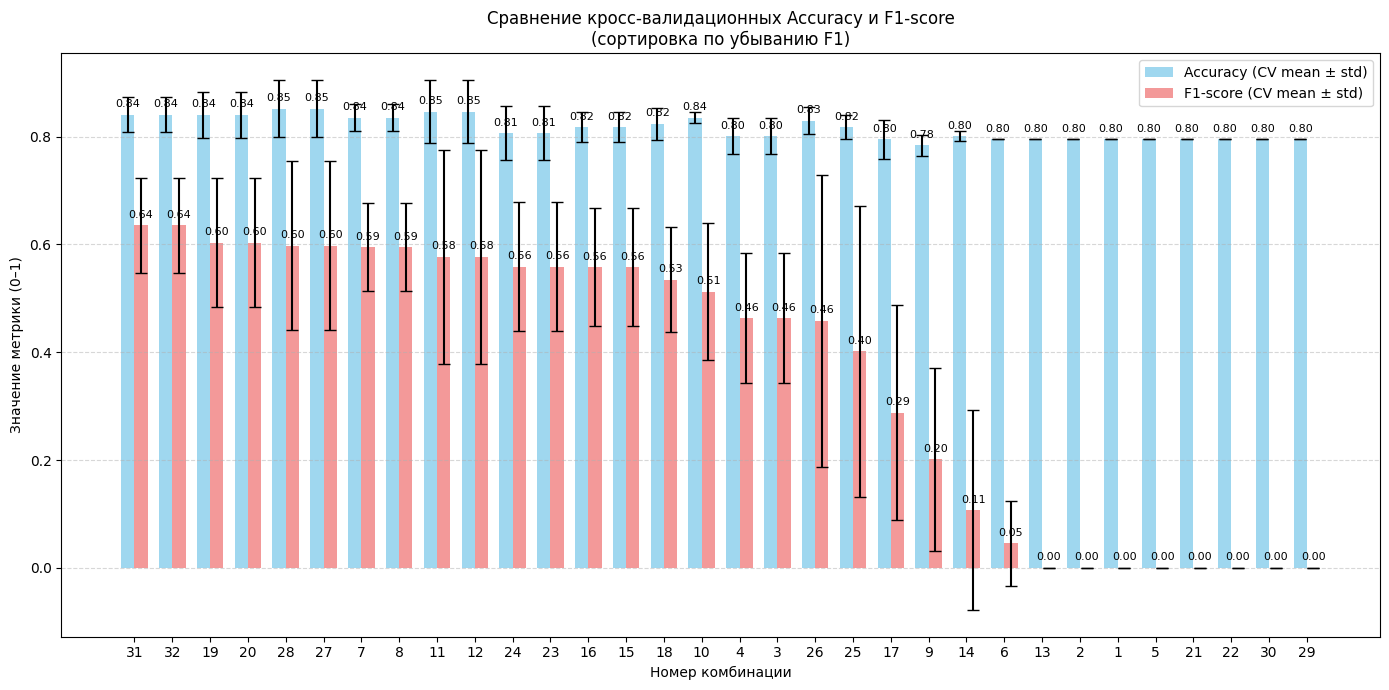

In [535]:
df_res_scaled_1layer = plot_results(df_res_scaled_1layer, 
                                     output_path='results/scaled/hyperparameter_tuning_histograms_1layer.png')

df_res_scaled_1layer.to_csv('results/scaled/hyperparameter_tuning_results_1layer.csv', index=False, encoding='utf-8')

In [536]:
display(df_res_scaled_1layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,31,"(100,)",tanh,lbfgs,1000,0.840909,0.032141,0.635781,0.088182
1,32,"(100,)",tanh,lbfgs,5000,0.840909,0.032141,0.635781,0.088182
2,19,"(50,)",relu,lbfgs,1000,0.840909,0.042519,0.603655,0.119702
3,20,"(50,)",relu,lbfgs,5000,0.840909,0.042519,0.603655,0.119702
4,28,"(100,)",relu,lbfgs,5000,0.852273,0.052075,0.597998,0.156420
5,27,"(100,)",relu,lbfgs,1000,0.852273,0.052075,0.597998,0.156420
6,7,"(10,)",tanh,lbfgs,1000,0.835227,0.024766,0.594869,0.081478
7,8,"(10,)",tanh,lbfgs,5000,0.835227,0.024766,0.594869,0.081478
8,11,"(20,)",relu,lbfgs,1000,0.846591,0.058773,0.577094,0.198678
9,12,"(20,)",relu,lbfgs,5000,0.846591,0.058773,0.577094,0.198678


Номер выборки - 31
Гиперпараметры - hidden_layer_sizes=(100,), activation='tanh', solver='lbfgs', max_iter=1000
Accuracy = 0.8409 ± 0.0321, F1-score = 0.6358 ± 0.0882


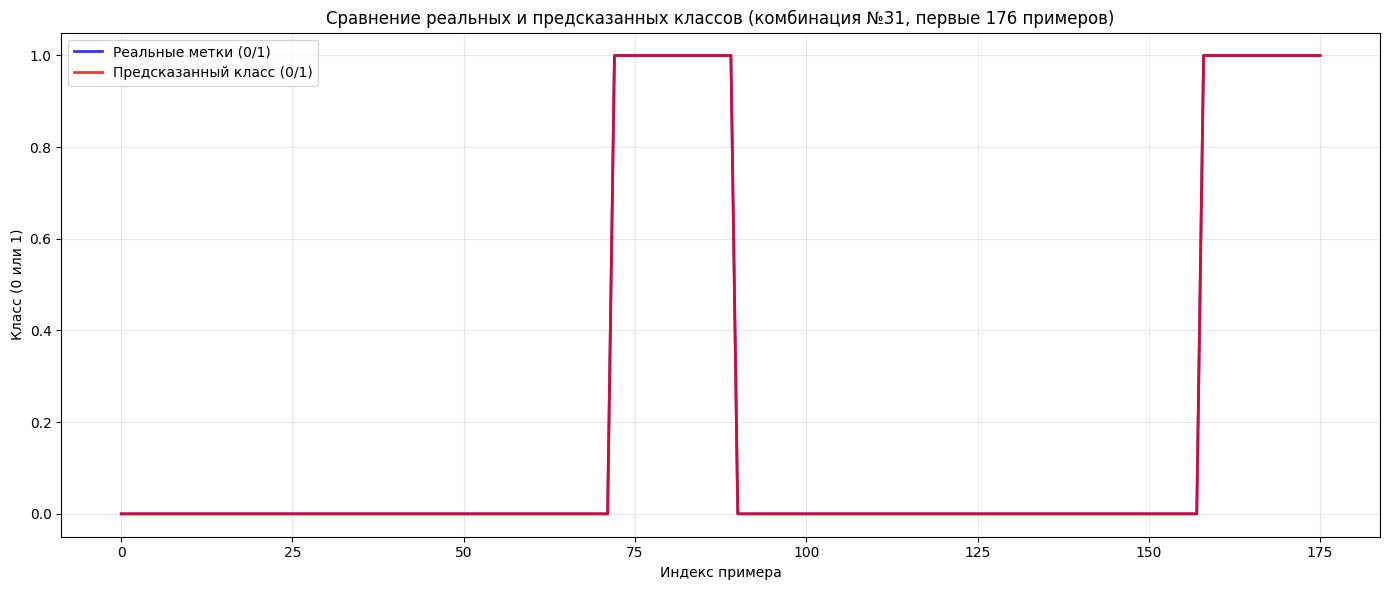

In [537]:
plot_model_by_combo_id(
    31,
    df_res_scaled_1layer,
    data_x_scaled,
    data_y,
    config['base']['random_state'],
    n_show=len(data_x_scaled),
    output_path='results/scaled/layer1_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 3.2 Тестирование с двумя слоями

In [538]:
hidden_opts = [(5, 5), 
               (10, 10), 
               (20, 10),
               (50, 20), 
               (100, 50)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [2500, 5000]

In [539]:
df_res_scaled_2layer = train_models(
    data_x_scaled, data_y,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=adam, max_iter=2500 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=lbfgs, max_iter=2500 → Accuracy: 0.733 (±0.081), F1-score: 0.133 (±0.176)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.733 (±0.081), F1-score: 0.133 (±0.176)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=tanh, solver=adam, max_iter=2500 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 7. Гиперпараметры: hidden_layer_siz

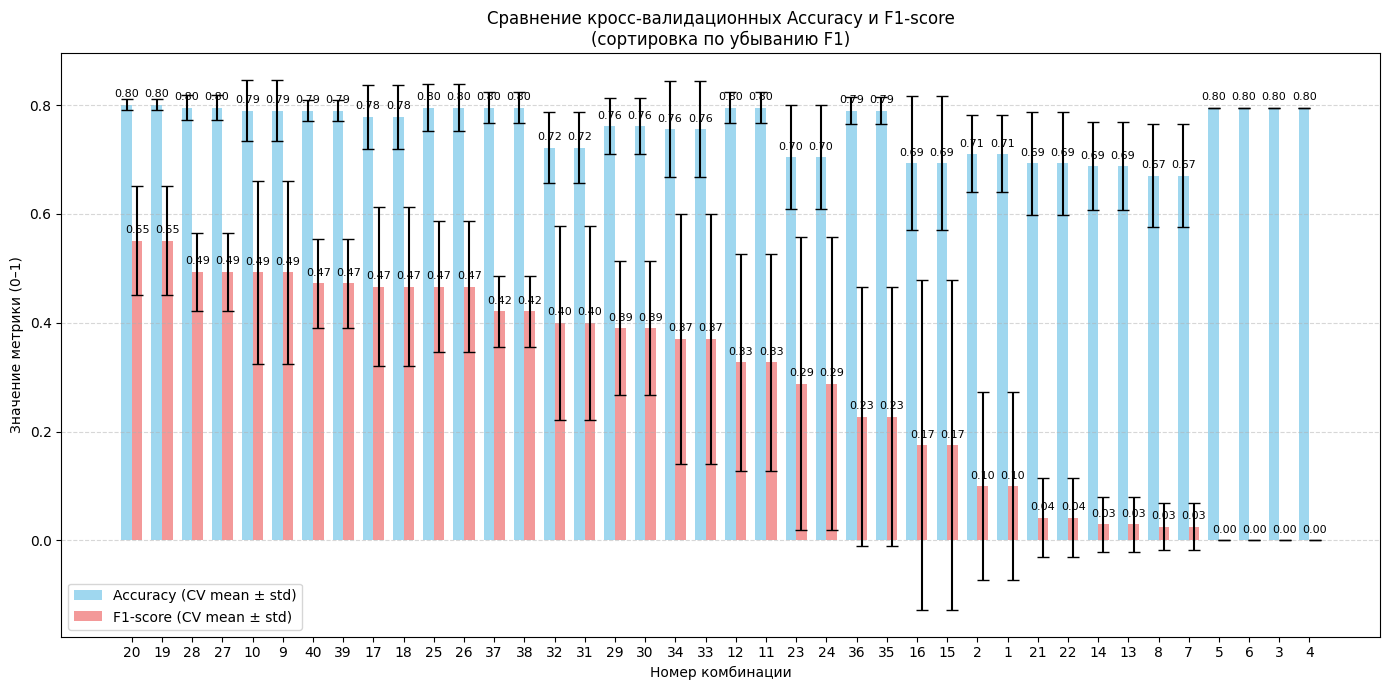

In [540]:
df_res_scaled_2layer = plot_results(df_res_without_2layer, 
                                     output_path='results/scaled/hyperparameter_tuning_histograms_2layer.png')

df_res_scaled_2layer.to_csv('results/scaled/hyperparameter_tuning_results_2layer.csv', index=False, encoding='utf-8')

In [541]:
display(df_res_scaled_2layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,20,"(20, 10)",relu,lbfgs,5000,0.801136,0.009841,0.550420,0.100146
1,19,"(20, 10)",relu,lbfgs,2500,0.801136,0.009841,0.550420,0.100146
2,28,"(50, 20)",relu,lbfgs,5000,0.795455,0.022727,0.494003,0.071822
3,27,"(50, 20)",relu,lbfgs,2500,0.795455,0.022727,0.494003,0.071822
4,10,"(10, 10)",relu,adam,5000,0.789773,0.056533,0.492423,0.168722
5,9,"(10, 10)",relu,adam,2500,0.789773,0.056533,0.492423,0.168722
6,40,"(100, 50)",tanh,lbfgs,5000,0.789773,0.018844,0.472508,0.081476
7,39,"(100, 50)",tanh,lbfgs,2500,0.789773,0.018844,0.472508,0.081476
8,17,"(20, 10)",relu,adam,2500,0.778409,0.058773,0.466560,0.145492
9,18,"(20, 10)",relu,adam,5000,0.778409,0.058773,0.466560,0.145492


Номер выборки - 20
Гиперпараметры - hidden_layer_sizes=(20, 10), activation='relu', solver='lbfgs', max_iter=5000
Accuracy = 0.8011 ± 0.0098, F1-score = 0.5504 ± 0.1001


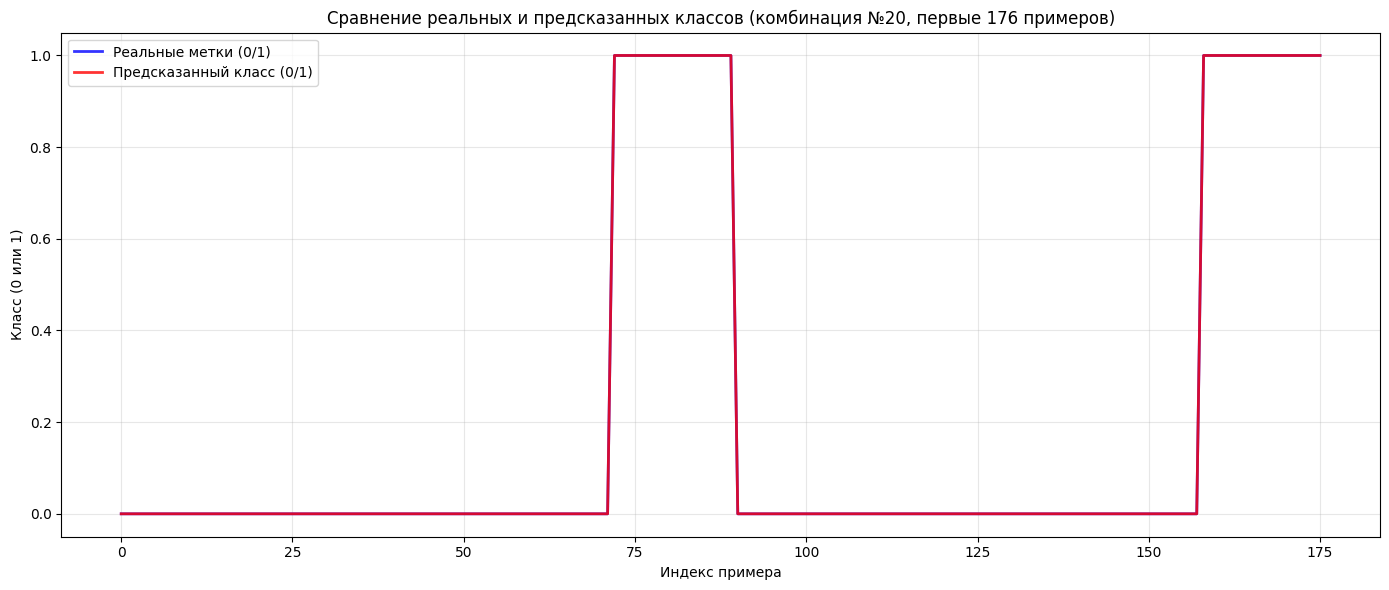

In [542]:
plot_model_by_combo_id(
    20,
    df_res_scaled_2layer,
    data_x_scaled,
    data_y,
    config['base']['random_state'],
    n_show=len(data_x_scaled),
    output_path='results/scaled/layer2_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 3.3 Тестирование с тремя слоями

In [543]:
hidden_opts = [ (5, 5, 5),
                (10, 10, 10),
                (50, 20, 10),
                (100, 50, 10),
                (100, 100, 50)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [5000]

In [544]:
df_res_scaled_3layer = train_models(
    data_x_scaled, data_y,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(5, 5, 5), activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.801 (±0.010), F1-score: 0.150 (±0.260)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(5, 5, 5), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.773 (±0.058), F1-score: 0.344 (±0.228)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(5, 5, 5), activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(5, 5, 5), activation=tanh, solver=lbfgs, max_iter=5000 → Accuracy: 0.801 (±0.037), F1-score: 0.516 (±0.068)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.830 (±0.020), F1-score: 0.599 (±0.058)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.847 (±0.010), F1-score: 0.629 (±0.074)
Номер набора № 7. Гиперпа

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 238 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 238 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Номер набора № 10. Гиперпараметры: hidden_layer_sizes=(50, 20, 10), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.818 (±0.051), F1-score: 0.532 (±0.111)
Номер набора № 11. Гиперпараметры: hidden_layer_sizes=(50, 20, 10), activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.807 (±0.011), F1-score: 0.284 (±0.288)
Номер набора № 12. Гиперпараметры: hidden_layer_sizes=(50, 20, 10), activation=tanh, solver=lbfgs, max_iter=5000 → Accuracy: 0.795 (±0.058), F1-score: 0.507 (±0.118)
Номер набора № 13. Гиперпараметры: hidden_layer_sizes=(100, 50, 10), activation=relu, solver=adam, max_iter=5000 → Accuracy: 0.869 (±0.041), F1-score: 0.645 (±0.108)
Номер набора № 14. Гиперпараметры: hidden_layer_sizes=(100, 50, 10), activation=relu, solver=lbfgs, max_iter=5000 → Accuracy: 0.841 (±0.043), F1-score: 0.601 (±0.070)
Номер набора № 15. Гиперпараметры: hidden_layer_sizes=(100, 50, 10), activation=tanh, solver=adam, max_iter=5000 → Accuracy: 0.801 (±0.025), F1-score: 0.430 (±0.258)
Номе

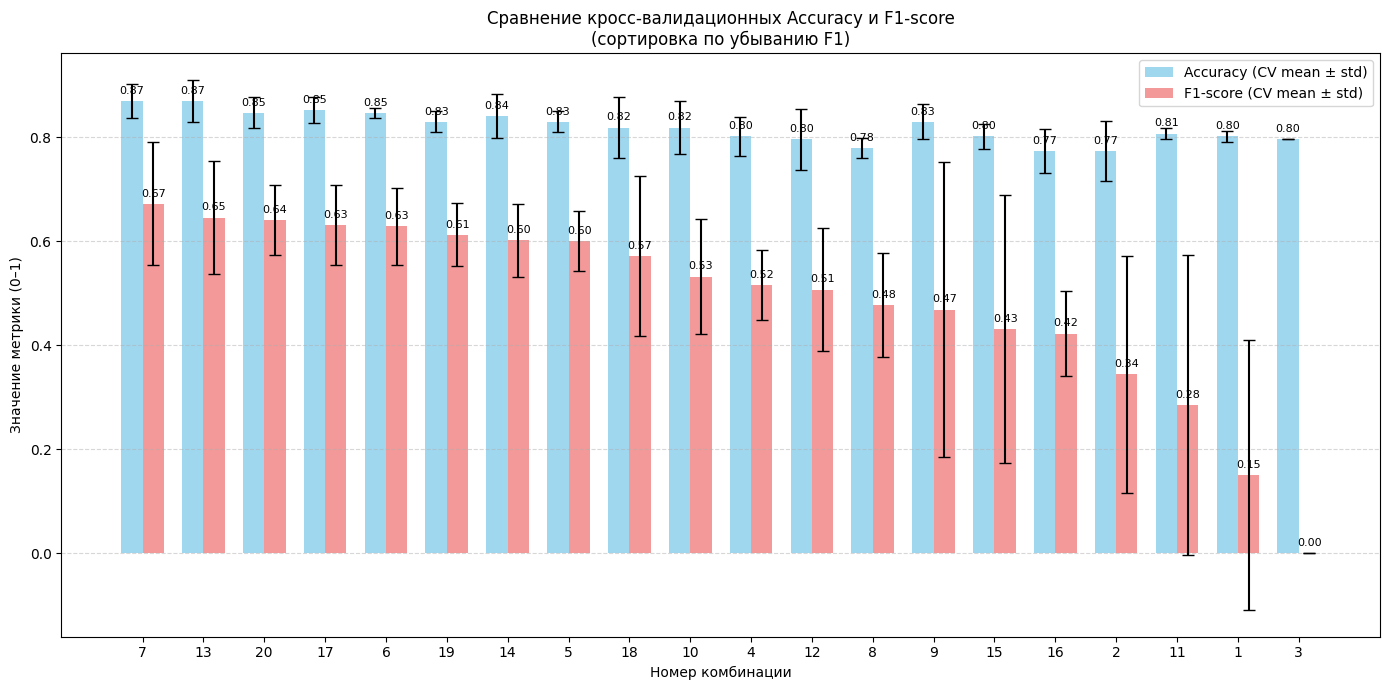

In [545]:
df_res_scaled_3layer = plot_results(df_res_scaled_3layer, 
                                     output_path='results/scaled/hyperparameter_tuning_histograms_3layer.png')

df_res_scaled_3layer.to_csv('results/scaled/hyperparameter_tuning_results_3layer.csv', index=False, encoding='utf-8')

In [546]:
display(df_res_scaled_3layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,7,"(10, 10, 10)",tanh,adam,5000,0.869318,0.033614,0.671726,0.118595
1,13,"(100, 50, 10)",relu,adam,5000,0.869318,0.040576,0.645075,0.108025
2,20,"(100, 100, 50)",tanh,lbfgs,5000,0.846591,0.029524,0.639912,0.066982
3,17,"(100, 100, 50)",relu,adam,5000,0.852273,0.025410,0.630392,0.076605
4,6,"(10, 10, 10)",relu,lbfgs,5000,0.846591,0.009841,0.628877,0.073977
5,19,"(100, 100, 50)",tanh,adam,5000,0.829545,0.019682,0.611869,0.060641
6,14,"(100, 50, 10)",relu,lbfgs,5000,0.840909,0.042519,0.601190,0.070178
7,5,"(10, 10, 10)",relu,adam,5000,0.829545,0.019682,0.599432,0.057594
8,18,"(100, 100, 50)",relu,lbfgs,5000,0.818182,0.057943,0.570868,0.153353
9,10,"(50, 20, 10)",relu,lbfgs,5000,0.818182,0.050820,0.531555,0.110637


Номер выборки - 20
Гиперпараметры - hidden_layer_sizes=(100, 100, 50), activation='tanh', solver='lbfgs', max_iter=5000
Accuracy = 0.8466 ± 0.0295, F1-score = 0.6399 ± 0.0670


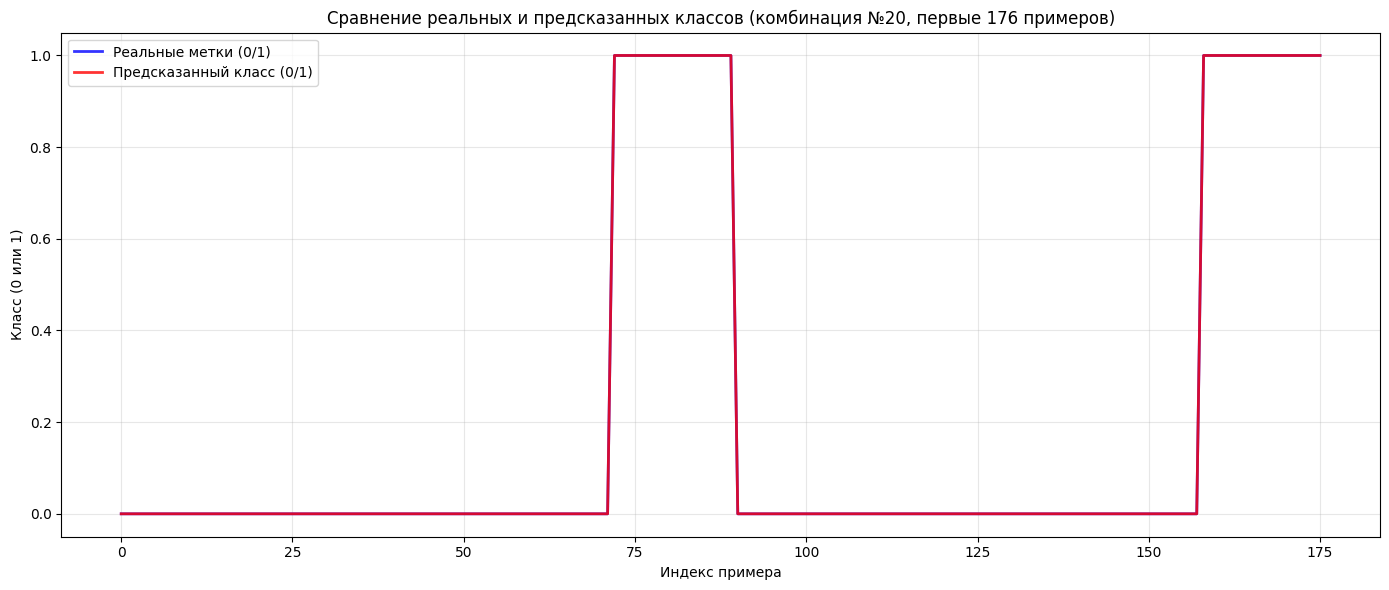

In [547]:
plot_model_by_combo_id(
    20,
    df_res_scaled_3layer,
    data_x_scaled,
    data_y,
    config['base']['random_state'],
    n_show=len(data_x_scaled),
    output_path='results/scaled/layer3_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 3.4 Подведение итогов

* **Лучший результат 1-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(50,), activation='relu', solver='lbfgs', max_iter=5000.
Accuracy = 0.8011 ± 0.0436, F1-score = 0.5470 ± 0.1046.

* **Лучший результат 1-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(50,), activation='tanh', solver='lbfgs', max_iter=1000.    
Accuracy = 0.7955 ± 0.0161, F1-score = 0.5201 ± 0.0415.

* **Лучший результат 1-го слоя (MinMaxScaled):**
Гиперпараметры - hidden_layer_sizes=(100,), activation='tanh', solver='lbfgs', max_iter=1000.   
Accuracy = 0.8409 ± 0.0321, F1-score = 0.6358 ± 0.0882.

* **Лучший результат 2-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(50, 20), activation='relu', solver='lbfgs', max_iter=1000.
Accuracy = 0.8068 ± 0.0197, F1-score = 0.5253 ± 0.0255.

* **Лучший результат 2-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=5000.     
Accuracy = 0.8352 ± 0.0373, F1-score = 0.5574 ± 0.0465.

* **Лучший результат 2-го слоя (MinMaxScaled):**
Гиперпараметры - hidden_layer_sizes=(20, 10), activation='relu', solver='lbfgs', max_iter=5000.     
Accuracy = 0.8011 ± 0.0098, F1-score = 0.5504 ± 0.1001.

* **Лучший результат 3-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(100, 50, 10), activation='tanh', solver='lbfgs', max_iter=5000.
Accuracy = 0.7500 ± 0.0359, F1-score = 0.4063 ± 0.0233.

* **Лучший результат 3-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(100, 100, 50), activation='relu', solver='adam', max_iter=5000.   
Accuracy = 0.8352 ± 0.0492, F1-score = 0.5858 ± 0.0430.

* **Лучший результат 3-го слоя (MinMaxScaled):**
*Гиперпараметры - hidden_layer_sizes=(100, 100, 50), activation='tanh', solver='lbfgs', max_iter=5000.*       
*Accuracy = 0.8466 ± 0.0295, F1-score = 0.6399 ± 0.0670.*

**Лучший результат: 3 слоя с нормализацией датасета**.

### <font color='#F5DEB3'>Задание №4

10. Провести балансировку классов через SMOTE и ADASYN
 
11. Провести  эксперимент  по  п.3  с  балансированными  данными  (необходимо  применить  оба 
алгоритма балансировки, в примере выше приведено использование алгоритма SMOTE, алгоритм 
ADASYN вызывается и используется абсолютно аналогично, необходимо лишь в импорте указать 
ADASYN вместо SMOTE, а также в строке с инициализацией алгоритма). При этом, в качестве 
выборки данных, которая загружается в переменную Data из Excel, необходимо выбрать ту (с 
нормализацией  или  без  нормализации),  на  которой  в  предыдущих  экспериментах  результат 
получился лучше всего по совокупности кросс-валидации и критерию F1. 
 
12.  Зафиксировать лучший полученный результат по п.8 – выставить в блокноте результат лучшего 
найденного результата обучения  (график и значения критериев понадобятся для отчёта).  
Добавить в блокноте новое поле ниже, выбрать вместо «Code», режим «Markdown» и написать 
заголовок:

#### <font color='#F5DEB3'> 4.1 Балансировка класса с SMOTE

In [8]:
smote = SMOTE(random_state=42)

X_smote, Y_smote = smote.fit_resample(data_x_scaled, data_y)


##### <font color='#F5DEB3'> 4.1.1 Тестирование с одним слоем

In [549]:
hidden_opts = [(10,), (50,), (100,)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [1000, 10000]

In [550]:
df_res_smote_1layer = train_models(
    X_smote, Y_smote,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.864 (±0.056), F1-score: 0.878 (±0.048)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=adam, max_iter=10000 → Accuracy: 0.868 (±0.047), F1-score: 0.881 (±0.039)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.896 (±0.057), F1-score: 0.905 (±0.051)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=lbfgs, max_iter=10000 → Accuracy: 0.896 (±0.057), F1-score: 0.905 (±0.051)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(10,), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.600 (±0.074), F1-score: 0.677 (±0.055)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(10,), activation=tanh, solver=adam, max_iter=10000 → Accuracy: 0.600 (±0.074), F1-score: 0.677 (±0.055)
Номер набора № 7. Гиперпараметры: hidden_layer_sizes=

c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Номер набора № 9. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.807 (±0.029), F1-score: 0.836 (±0.022)
Номер набора № 10. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=adam, max_iter=10000 → Accuracy: 0.807 (±0.029), F1-score: 0.836 (±0.022)
Номер набора № 11. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.918 (±0.038), F1-score: 0.923 (±0.036)
Номер набора № 12. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=lbfgs, max_iter=10000 → Accuracy: 0.918 (±0.038), F1-score: 0.923 (±0.036)
Номер набора № 13. Гиперпараметры: hidden_layer_sizes=(50,), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.539 (±0.041), F1-score: 0.663 (±0.032)
Номер набора № 14. Гиперпараметры: hidden_layer_sizes=(50,), activation=tanh, solver=adam, max_iter=10000 → Accuracy: 0.539 (±0.041), F1-score: 0.663 (±0.032)
Номер набора № 15. Гиперпараметры: hidden_layer_

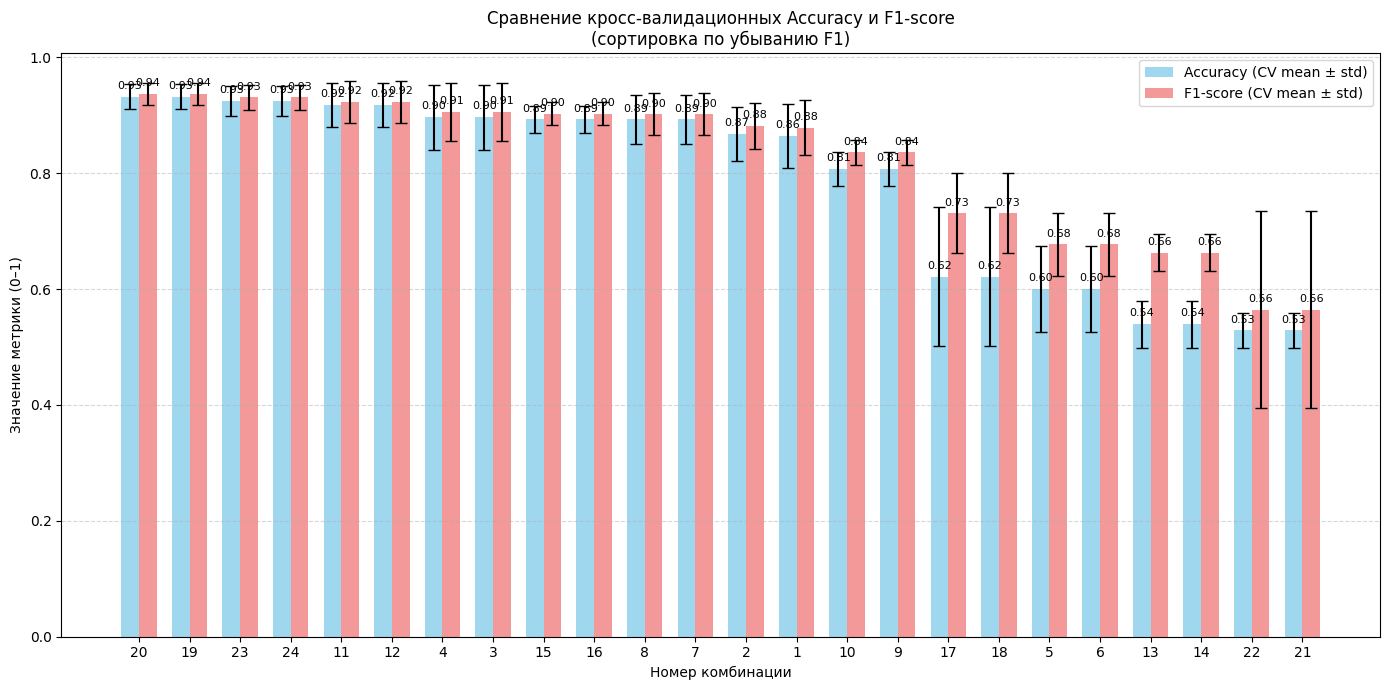

In [551]:
df_res_smote_1layer = plot_results(df_res_smote_1layer, 
                                     output_path='results/smote/hyperparameter_tuning_histograms_1layer.png')

df_res_smote_1layer.to_csv('results/smote/hyperparameter_tuning_results_1layer.csv', index=False, encoding='utf-8')

In [552]:
display(df_res_smote_1layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,20,"(100,)",relu,lbfgs,10000,0.932143,0.021129,0.936213,0.019306
1,19,"(100,)",relu,lbfgs,1000,0.932143,0.021129,0.936213,0.019306
2,23,"(100,)",tanh,lbfgs,1000,0.925000,0.025505,0.930752,0.021885
3,24,"(100,)",tanh,lbfgs,10000,0.925000,0.025505,0.930752,0.021885
4,11,"(50,)",relu,lbfgs,1000,0.917857,0.038299,0.922692,0.036051
5,12,"(50,)",relu,lbfgs,10000,0.917857,0.038299,0.922692,0.036051
6,4,"(10,)",relu,lbfgs,10000,0.896429,0.056582,0.905470,0.050705
7,3,"(10,)",relu,lbfgs,1000,0.896429,0.056582,0.905470,0.050705
8,15,"(50,)",tanh,lbfgs,1000,0.892857,0.023690,0.902834,0.020349
9,16,"(50,)",tanh,lbfgs,10000,0.892857,0.023690,0.902834,0.020349


Номер выборки - 20
Гиперпараметры - hidden_layer_sizes=(100,), activation='relu', solver='lbfgs', max_iter=10000
Accuracy = 0.9321 ± 0.0211, F1-score = 0.9362 ± 0.0193


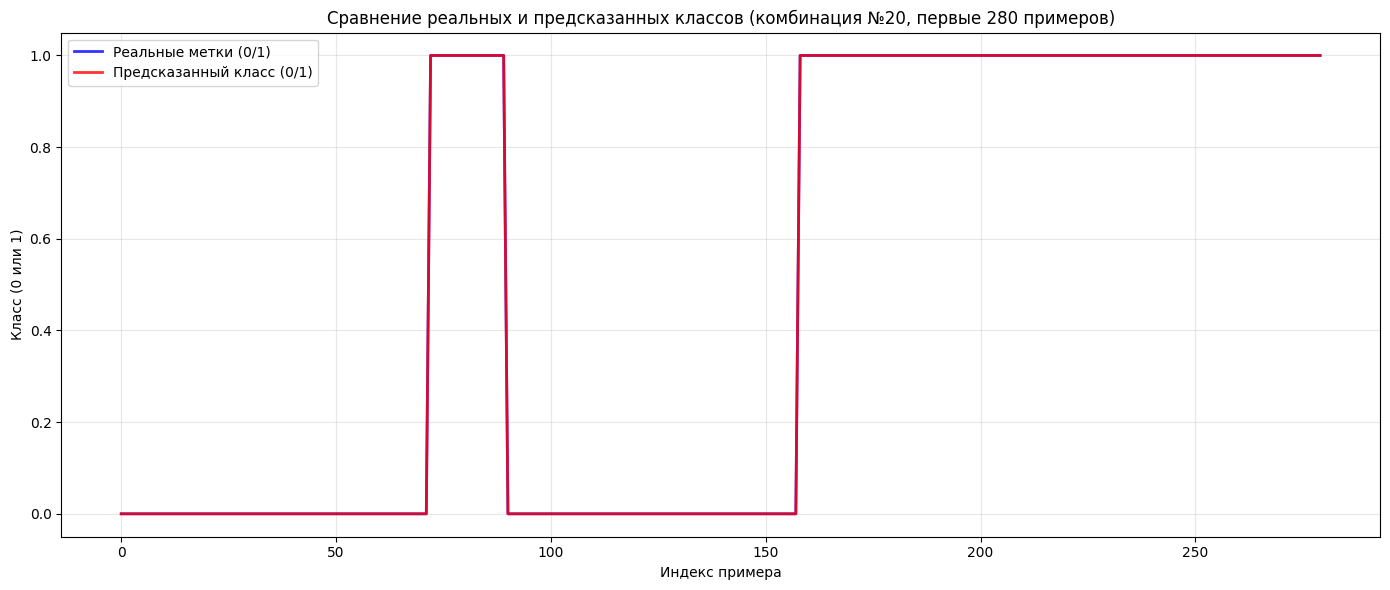

In [553]:
plot_model_by_combo_id(
    20,
    df_res_smote_1layer,
    X_smote,
    Y_smote,
    config['base']['random_state'],
    len(X_smote)
)

##### <font color='#F5DEB3'> 4.1.2 Тестирование с двумя слоями

In [554]:
hidden_opts = [(10, 10), (20, 10), (30, 15), (50, 20), (100, 10)]
act_opts = ['relu']
solv_opts = ['adam', 'lbfgs']
iter_opts = [1000, 10000]

In [555]:
df_res_smote_2layer = train_models(
    X_smote, Y_smote,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.871 (±0.058), F1-score: 0.886 (±0.048)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=relu, solver=adam, max_iter=10000 → Accuracy: 0.871 (±0.058), F1-score: 0.886 (±0.048)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.886 (±0.042), F1-score: 0.891 (±0.043)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=relu, solver=lbfgs, max_iter=10000 → Accuracy: 0.886 (±0.042), F1-score: 0.891 (±0.043)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.825 (±0.077), F1-score: 0.847 (±0.064)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=adam, max_iter=10000 → Accuracy: 0.825 (±0.077), F1-score: 0.847 (±0.064)
Номер набора № 7. Гиперпараметры: h

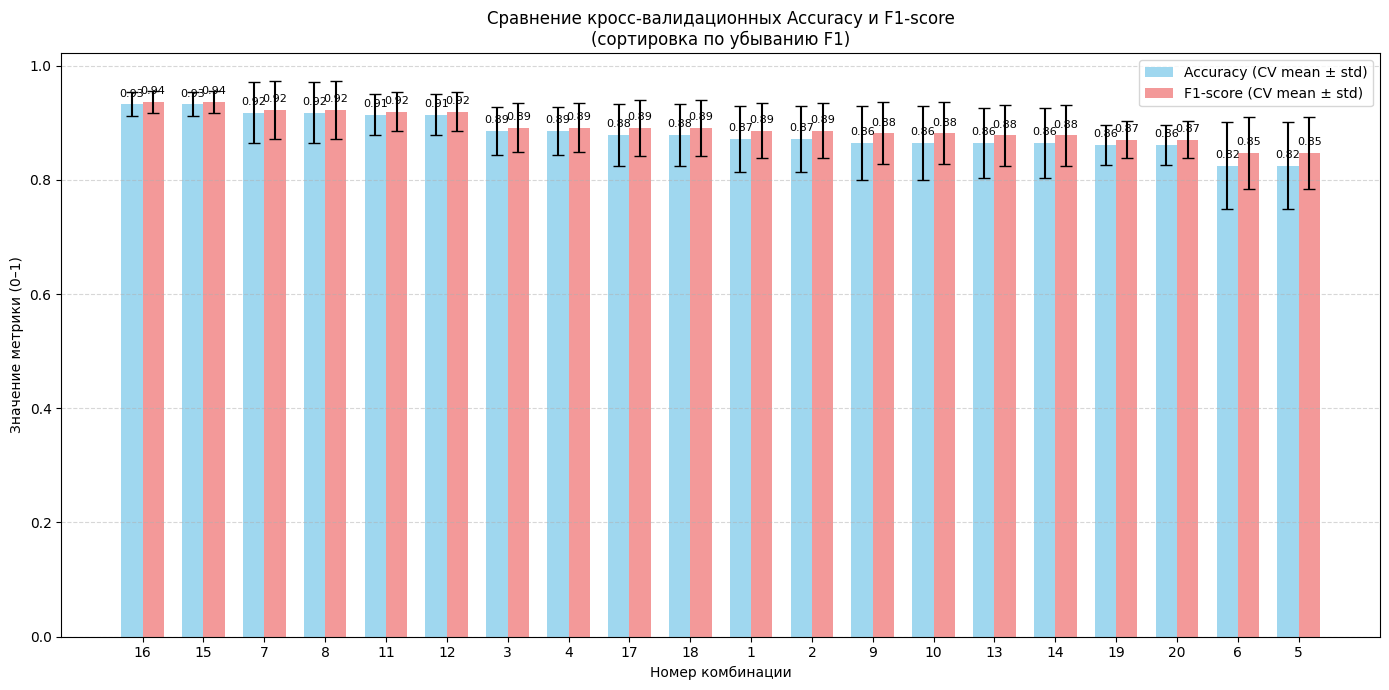

In [556]:
df_res_smote_2layer = plot_results(df_res_smote_2layer, 
                                     output_path='results/smote/hyperparameter_tuning_histograms_2layer.png')

df_res_smote_2layer.to_csv('results/smote/hyperparameter_tuning_results_2layer.csv', index=False, encoding='utf-8')

In [557]:
display(df_res_smote_2layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,16,"(50, 20)",relu,lbfgs,10000,0.932143,0.021129,0.936362,0.018488
1,15,"(50, 20)",relu,lbfgs,1000,0.932143,0.021129,0.936362,0.018488
2,7,"(20, 10)",relu,lbfgs,1000,0.917857,0.052852,0.922567,0.050267
3,8,"(20, 10)",relu,lbfgs,10000,0.917857,0.052852,0.922567,0.050267
4,11,"(30, 15)",relu,lbfgs,1000,0.914286,0.036422,0.919075,0.034261
5,12,"(30, 15)",relu,lbfgs,10000,0.914286,0.036422,0.919075,0.034261
6,3,"(10, 10)",relu,lbfgs,1000,0.885714,0.041650,0.891491,0.043300
7,4,"(10, 10)",relu,lbfgs,10000,0.885714,0.041650,0.891491,0.043300
8,17,"(100, 10)",relu,adam,1000,0.878571,0.054865,0.891082,0.048733
9,18,"(100, 10)",relu,adam,10000,0.878571,0.054865,0.891082,0.048733


Номер выборки - 16
Гиперпараметры - hidden_layer_sizes=(50, 20), activation='relu', solver='lbfgs', max_iter=10000
Accuracy = 0.9321 ± 0.0211, F1-score = 0.9364 ± 0.0185


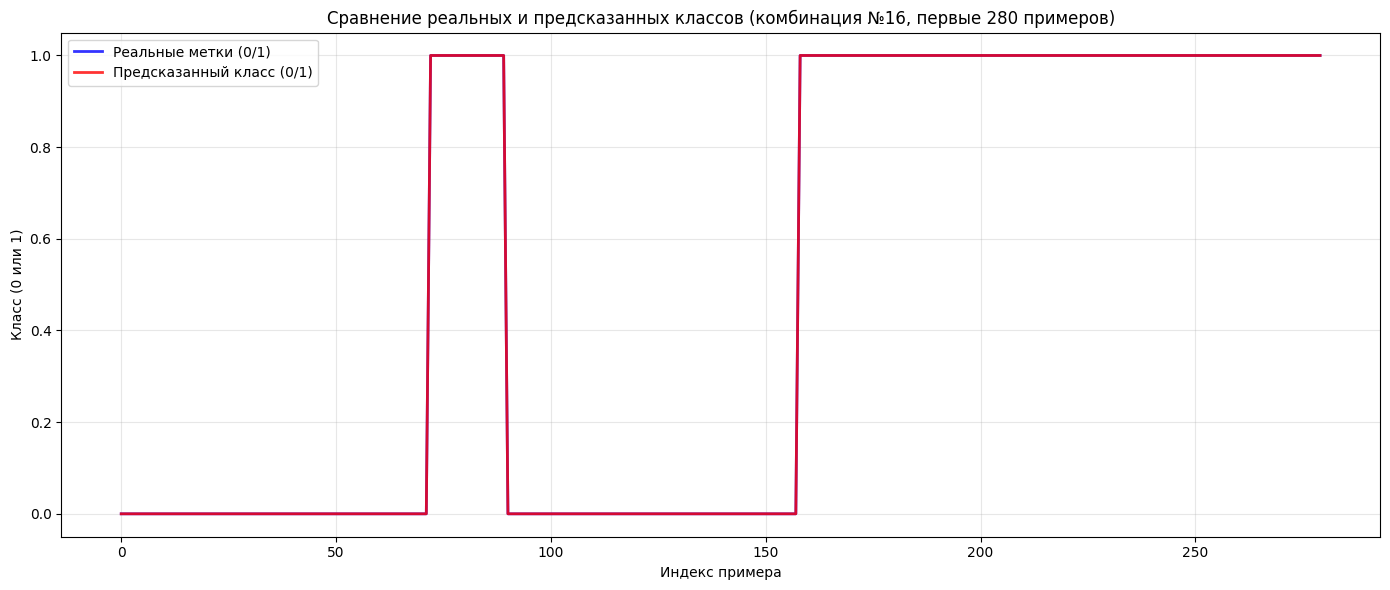

In [558]:
plot_model_by_combo_id(
    16,
    df_res_smote_2layer,
    X_smote,
    Y_smote,
    config['base']['random_state'],
    len(X_smote)
)

##### <font color='#F5DEB3'> 4.1.3 Тестирование с тремя слоями

In [559]:
hidden_opts = [ (10, 10, 10),
                (20, 10, 10),
                (50, 20, 10),
                (100, 50, 10),
                (100, 50, 50)]
act_opts = ['relu']
solv_opts = ['adam', 'lbfgs']
iter_opts = [1000, 10000]

In [560]:
df_res_smote_3layer = train_models(
    X_smote, Y_smote,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.886 (±0.072), F1-score: 0.897 (±0.062)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=adam, max_iter=10000 → Accuracy: 0.886 (±0.072), F1-score: 0.897 (±0.062)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.893 (±0.031), F1-score: 0.902 (±0.027)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=lbfgs, max_iter=10000 → Accuracy: 0.893 (±0.031), F1-score: 0.902 (±0.027)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(20, 10, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.861 (±0.040), F1-score: 0.878 (±0.032)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(20, 10, 10), activation=relu, solver=adam, max_iter=10000 → Accuracy: 0.861 (±0.040), F1-score: 0.878 (±0.032)
Номер набор

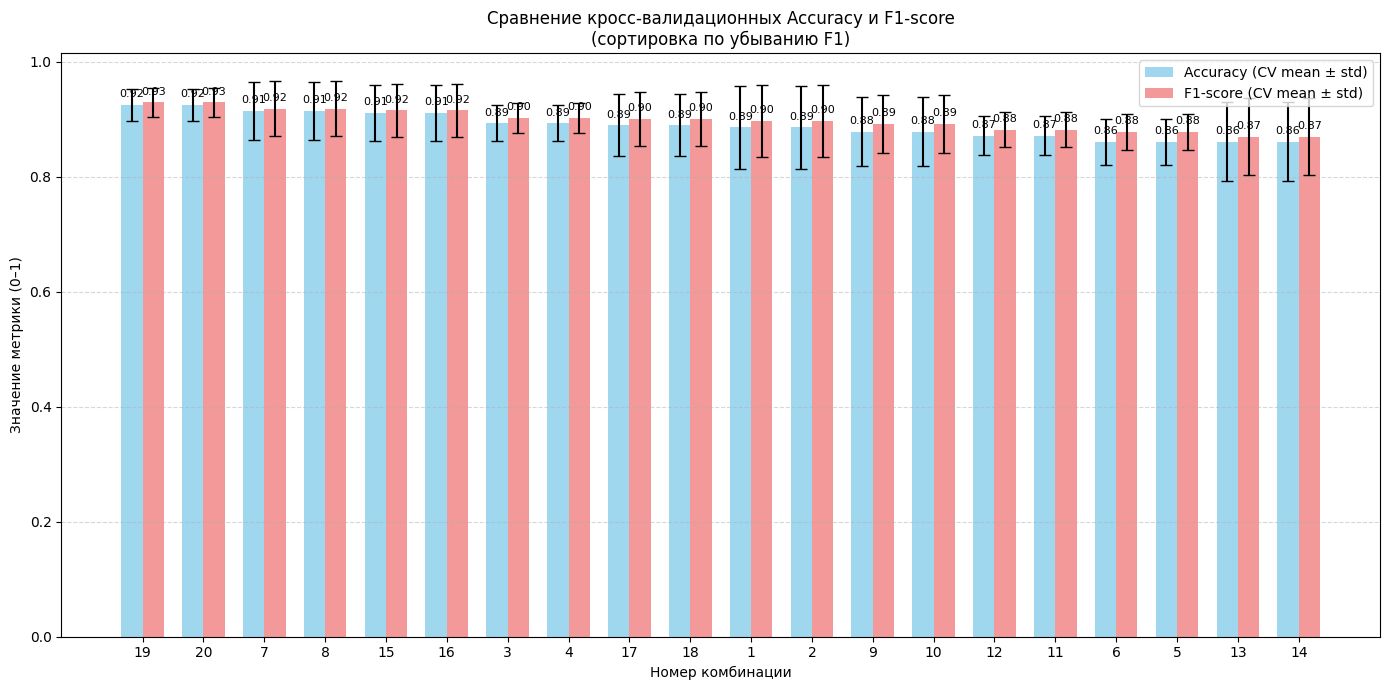

In [561]:
df_res_smote_3layer = plot_results(df_res_smote_3layer, 
                                     output_path='results/smote/hyperparameter_tuning_histograms_3layer.png')

df_res_smote_3layer.to_csv('results/smote/hyperparameter_tuning_results_3layer.csv', index=False, encoding='utf-8')

In [562]:
display(df_res_smote_3layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,19,"(100, 50, 50)",relu,lbfgs,1000,0.925000,0.027433,0.929152,0.025407
1,20,"(100, 50, 50)",relu,lbfgs,10000,0.925000,0.027433,0.929152,0.025407
2,7,"(20, 10, 10)",relu,lbfgs,1000,0.914286,0.050508,0.918549,0.047595
3,8,"(20, 10, 10)",relu,lbfgs,10000,0.914286,0.050508,0.918549,0.047595
4,15,"(100, 50, 10)",relu,lbfgs,1000,0.910714,0.048839,0.915396,0.046069
5,16,"(100, 50, 10)",relu,lbfgs,10000,0.910714,0.048839,0.915396,0.046069
6,3,"(10, 10, 10)",relu,lbfgs,1000,0.892857,0.031135,0.901894,0.026529
7,4,"(10, 10, 10)",relu,lbfgs,10000,0.892857,0.031135,0.901894,0.026529
8,17,"(100, 50, 50)",relu,adam,1000,0.889286,0.053809,0.900617,0.046962
9,18,"(100, 50, 50)",relu,adam,10000,0.889286,0.053809,0.900617,0.046962


Номер выборки - 19
Гиперпараметры - hidden_layer_sizes=(100, 50, 50), activation='relu', solver='lbfgs', max_iter=1000
Accuracy = 0.9250 ± 0.0274, F1-score = 0.9292 ± 0.0254


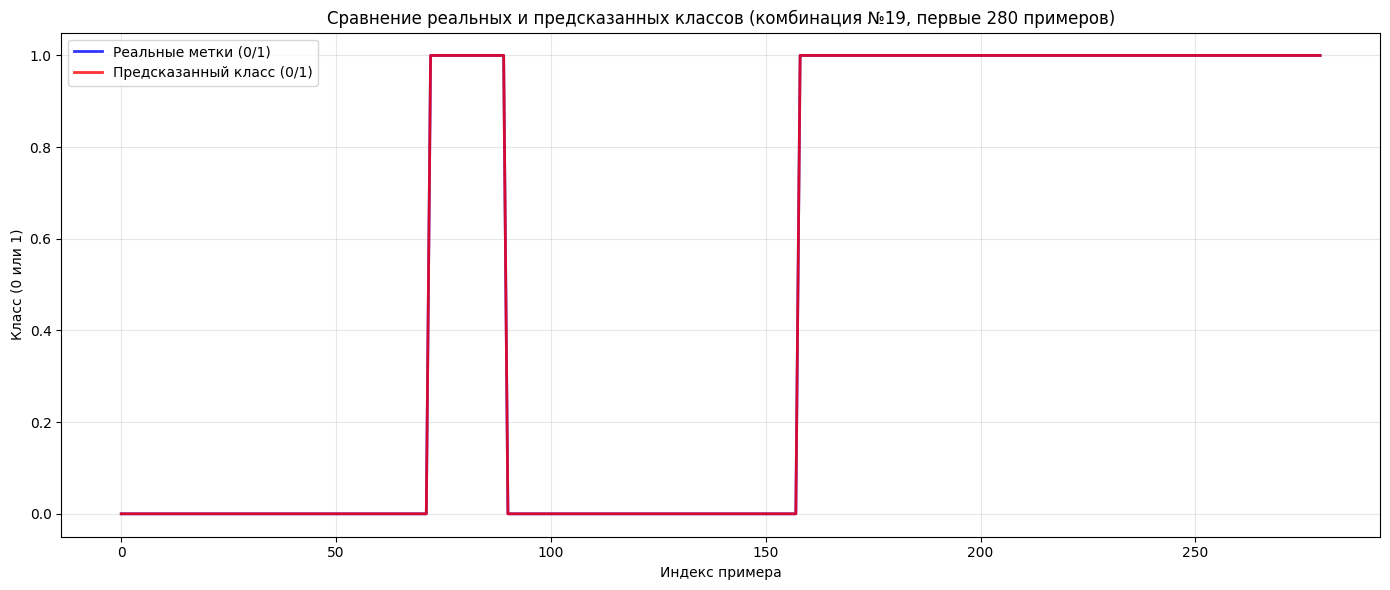

In [563]:
plot_model_by_combo_id(
    19,
    df_res_smote_3layer,
    X_smote,
    Y_smote,
    config['base']['random_state'],
    len(X_smote)
)

#### <font color='#F5DEB3'> 4.2 Балансировка класса с ADASYN

In [9]:
adasyn = ADASYN(random_state=42)

X_adasyn, Y_adasyn = adasyn.fit_resample(data_x_scaled, data_y)

##### <font color='#F5DEB3'> 4.2.1 Тестирование с одним слоем

In [565]:
hidden_opts = [(10,), (50,), (100,)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [1000, 10000]

In [566]:
df_res_adasyn_1layer = train_models(
    X_adasyn, Y_adasyn,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.651 (±0.091), F1-score: 0.610 (±0.108)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=adam, max_iter=10000 → Accuracy: 0.651 (±0.091), F1-score: 0.610 (±0.108)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.868 (±0.040), F1-score: 0.870 (±0.041)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=lbfgs, max_iter=10000 → Accuracy: 0.868 (±0.040), F1-score: 0.870 (±0.041)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(10,), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.574 (±0.094), F1-score: 0.574 (±0.108)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(10,), activation=tanh, solver=adam, max_iter=10000 → Accuracy: 0.574 (±0.094), F1-score: 0.574 (±0.108)
Номер набора № 7. Гиперпараметры: hidden_layer_sizes=

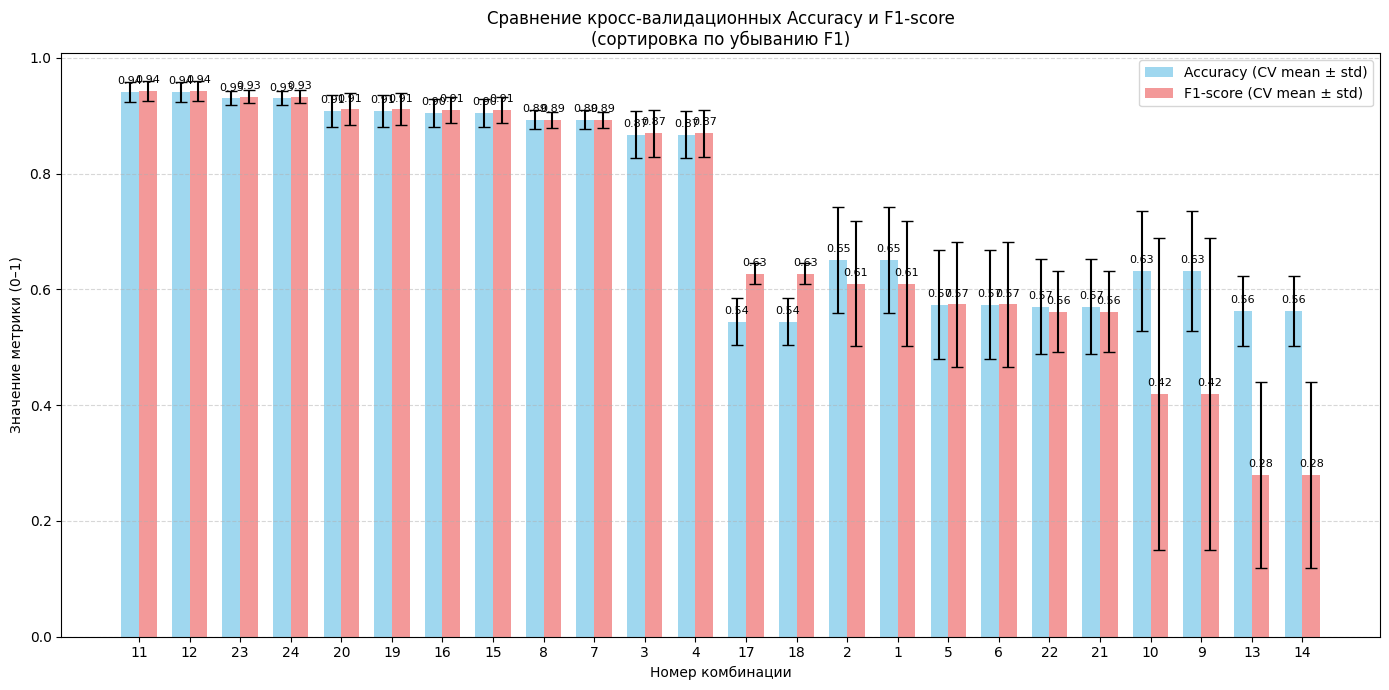

In [567]:
df_res_adasyn_1layer = plot_results(df_res_adasyn_1layer, 
                                     output_path='results/adasyn/hyperparameter_tuning_histograms_1layer.png')

df_res_adasyn_1layer.to_csv('results/adasyn/hyperparameter_tuning_results_1layer.csv', index=False, encoding='utf-8')

In [568]:
display(df_res_adasyn_1layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,11,"(50,)",relu,lbfgs,1000,0.941176,0.018011,0.942547,0.017244
1,12,"(50,)",relu,lbfgs,10000,0.941176,0.018011,0.942547,0.017244
2,23,"(100,)",tanh,lbfgs,1000,0.930147,0.012193,0.932990,0.010872
3,24,"(100,)",tanh,lbfgs,10000,0.930147,0.012193,0.932990,0.010872
4,20,"(100,)",relu,lbfgs,10000,0.908088,0.028240,0.911017,0.027625
5,19,"(100,)",relu,lbfgs,1000,0.908088,0.028240,0.911017,0.027625
6,16,"(50,)",tanh,lbfgs,10000,0.904412,0.024387,0.909994,0.021848
7,15,"(50,)",tanh,lbfgs,1000,0.904412,0.024387,0.909994,0.021848
8,8,"(10,)",tanh,lbfgs,10000,0.893382,0.016025,0.892472,0.013791
9,7,"(10,)",tanh,lbfgs,1000,0.893382,0.016025,0.892472,0.013791


Номер выборки - 11
Гиперпараметры - hidden_layer_sizes=(50,), activation='relu', solver='lbfgs', max_iter=1000
Accuracy = 0.9412 ± 0.0180, F1-score = 0.9425 ± 0.0172


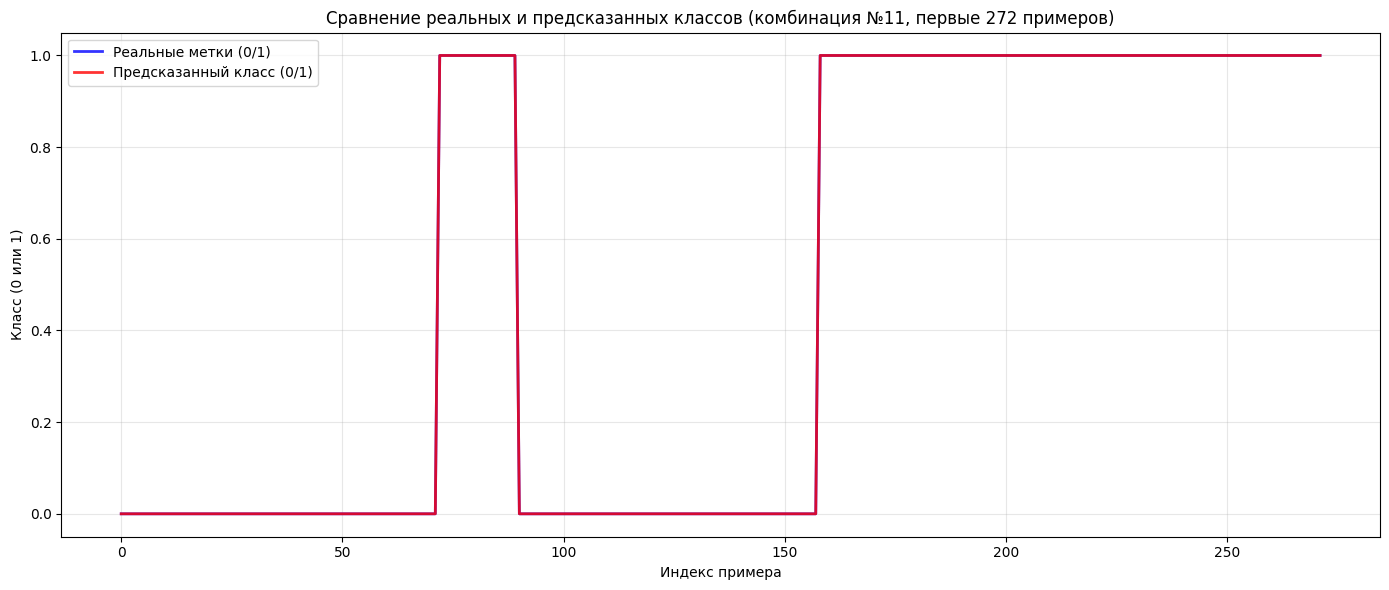

In [569]:
plot_model_by_combo_id(
    11,
    df_res_adasyn_1layer,
    X_adasyn,
    Y_adasyn,
    config['base']['random_state'],
    len(X_adasyn)
)

##### <font color='#F5DEB3'> 4.2.2 Тестирование с двумя слоями

In [570]:
hidden_opts = [(10, 10), (20, 10), (30, 15), (50, 20), (100, 10)]
act_opts = ['relu']
solv_opts = ['adam', 'lbfgs']
iter_opts = [1000, 10000]

In [571]:
df_res_adasyn_2layer = train_models(
    X_adasyn, Y_adasyn,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.739 (±0.016), F1-score: 0.771 (±0.016)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=relu, solver=adam, max_iter=10000 → Accuracy: 0.739 (±0.016), F1-score: 0.771 (±0.016)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.897 (±0.067), F1-score: 0.894 (±0.071)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(10, 10), activation=relu, solver=lbfgs, max_iter=10000 → Accuracy: 0.897 (±0.067), F1-score: 0.894 (±0.071)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.566 (±0.057), F1-score: 0.416 (±0.099)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=adam, max_iter=10000 → Accuracy: 0.566 (±0.057), F1-score: 0.416 (±0.099)
Номер набора № 7. Гиперпараметры: h

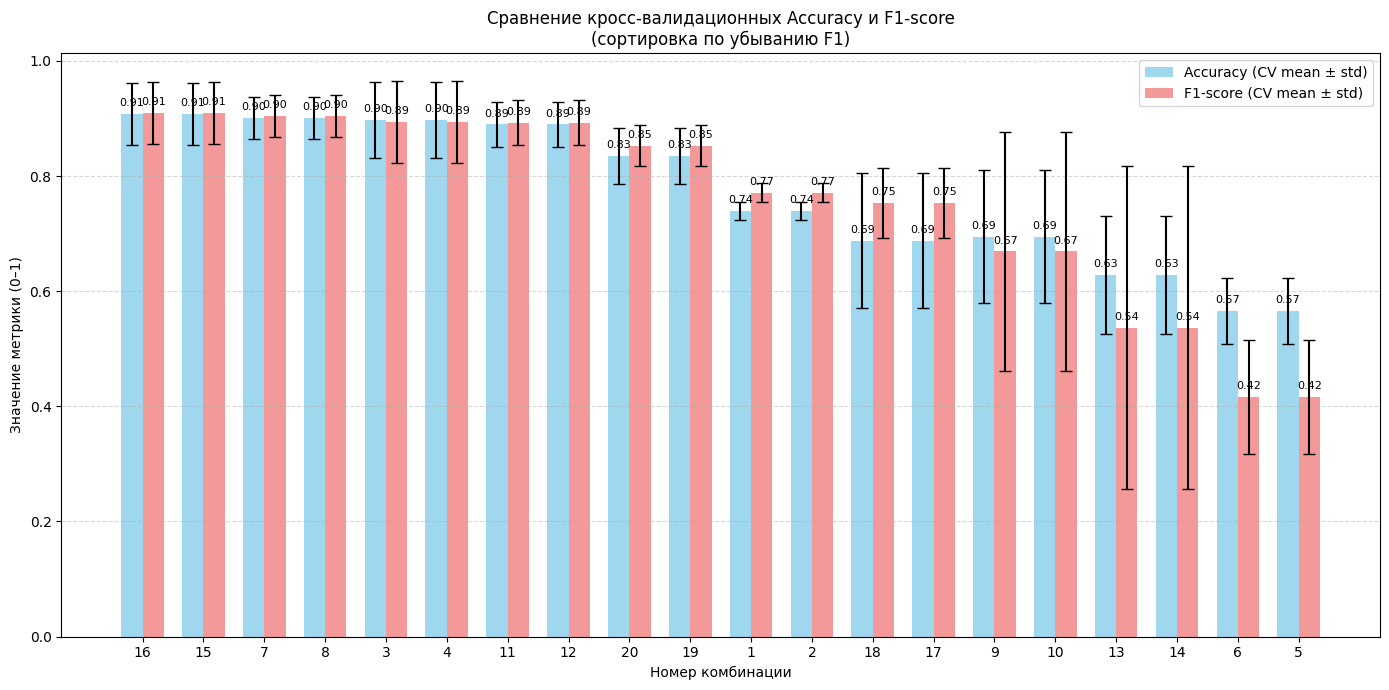

In [572]:
df_res_adasyn_2layer = plot_results(df_res_adasyn_2layer, 
                                     output_path='results/adasyn/hyperparameter_tuning_histograms_2layer.png')

df_res_adasyn_2layer.to_csv('results/adasyn/hyperparameter_tuning_results_2layer.csv', index=False, encoding='utf-8')

In [573]:
display(df_res_adasyn_2layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,16,"(50, 20)",relu,lbfgs,10000,0.908088,0.053404,0.909495,0.053732
1,15,"(50, 20)",relu,lbfgs,1000,0.908088,0.053404,0.909495,0.053732
2,7,"(20, 10)",relu,lbfgs,1000,0.900735,0.036580,0.904100,0.037050
3,8,"(20, 10)",relu,lbfgs,10000,0.900735,0.036580,0.904100,0.037050
4,3,"(10, 10)",relu,lbfgs,1000,0.897059,0.066584,0.893535,0.071226
5,4,"(10, 10)",relu,lbfgs,10000,0.897059,0.066584,0.893535,0.071226
6,11,"(30, 15)",relu,lbfgs,1000,0.889706,0.039597,0.892730,0.039338
7,12,"(30, 15)",relu,lbfgs,10000,0.889706,0.039597,0.892730,0.039338
8,20,"(100, 10)",relu,lbfgs,10000,0.834559,0.049188,0.852662,0.035912
9,19,"(100, 10)",relu,lbfgs,1000,0.834559,0.049188,0.852662,0.035912


Номер выборки - 7
Гиперпараметры - hidden_layer_sizes=(20, 10), activation='relu', solver='lbfgs', max_iter=1000
Accuracy = 0.9007 ± 0.0366, F1-score = 0.9041 ± 0.0371


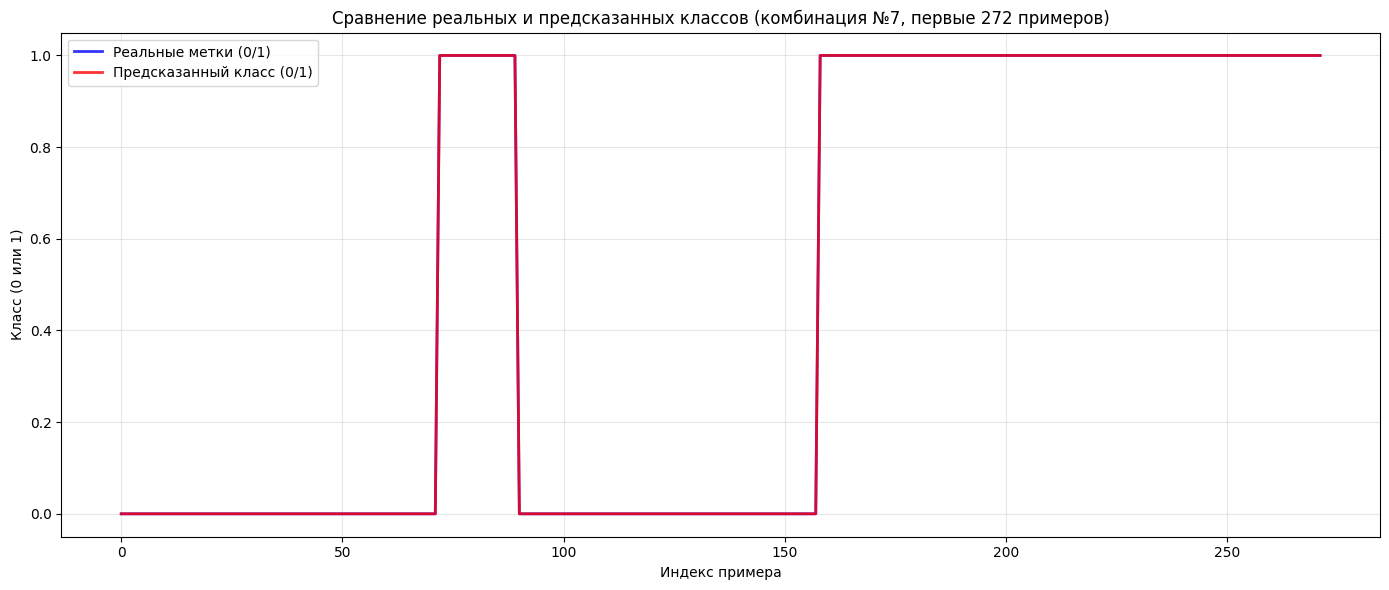

In [574]:
plot_model_by_combo_id(
    7,
    df_res_adasyn_2layer,
    X_adasyn,
    Y_adasyn,
    config['base']['random_state'],
    len(X_adasyn)
)

##### <font color='#F5DEB3'> 4.2.3 Тестирование с тремя слоями

In [575]:
hidden_opts = [ (10, 10, 10),
                (20, 10, 10),
                (50, 20, 10),
                (100, 50, 10),
                (100, 50, 50)]
act_opts = ['relu']
solv_opts = ['adam', 'lbfgs']
iter_opts = [1000, 10000]

In [576]:
df_res_adasyn_3layer = train_models(
    X_adasyn, Y_adasyn,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.739 (±0.098), F1-score: 0.694 (±0.213)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=adam, max_iter=10000 → Accuracy: 0.739 (±0.098), F1-score: 0.694 (±0.213)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.908 (±0.052), F1-score: 0.910 (±0.053)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=lbfgs, max_iter=10000 → Accuracy: 0.908 (±0.052), F1-score: 0.910 (±0.053)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(20, 10, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.581 (±0.051), F1-score: 0.500 (±0.119)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(20, 10, 10), activation=relu, solver=adam, max_iter=10000 → Accuracy: 0.581 (±0.051), F1-score: 0.500 (±0.119)
Номер набор

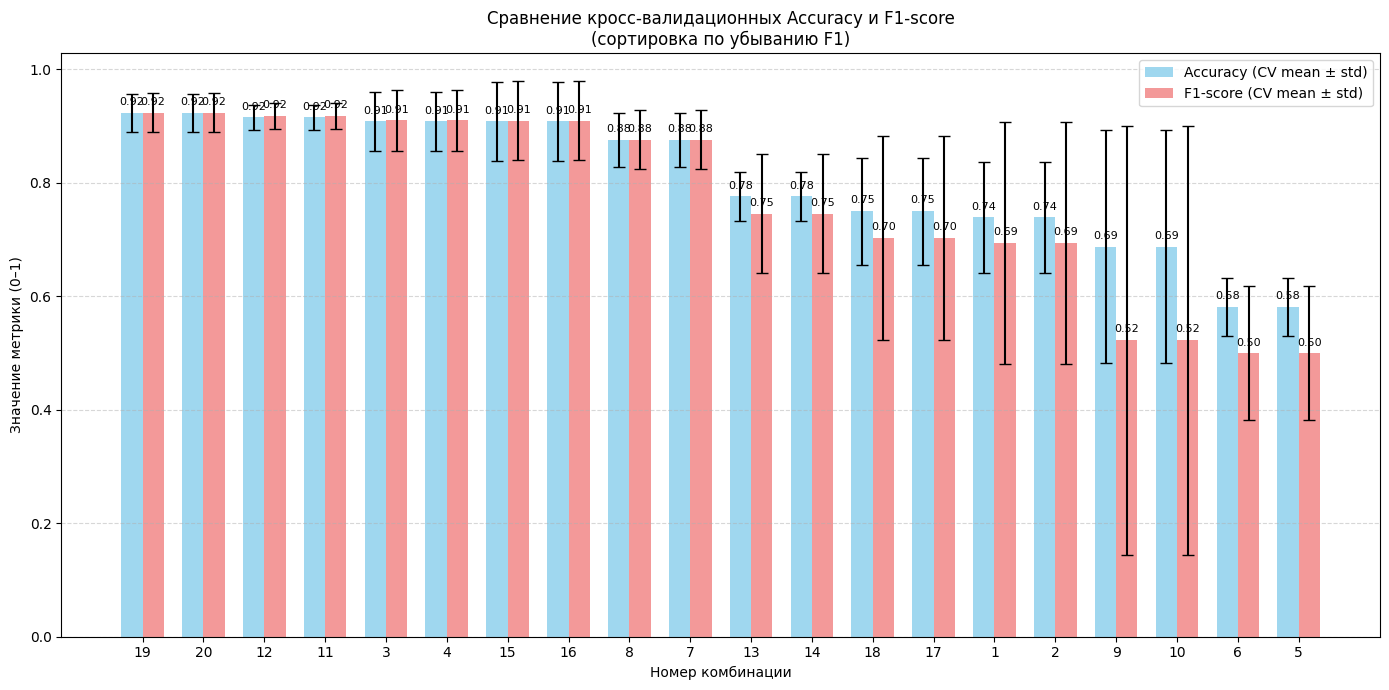

In [577]:
df_res_adasyn_3layer = plot_results(df_res_adasyn_3layer, 
                                     output_path='results/adasyn/hyperparameter_tuning_histograms_3layer.png')

df_res_adasyn_3layer.to_csv('results/adasyn/hyperparameter_tuning_results_3layer.csv', index=False, encoding='utf-8')

In [578]:
display(df_res_adasyn_3layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,19,"(100, 50, 50)",relu,lbfgs,1000,0.922794,0.033494,0.923657,0.034807
1,20,"(100, 50, 50)",relu,lbfgs,10000,0.922794,0.033494,0.923657,0.034807
2,12,"(50, 20, 10)",relu,lbfgs,10000,0.915441,0.021750,0.917864,0.022496
3,11,"(50, 20, 10)",relu,lbfgs,1000,0.915441,0.021750,0.917864,0.022496
4,3,"(10, 10, 10)",relu,lbfgs,1000,0.908088,0.052382,0.909743,0.053049
5,4,"(10, 10, 10)",relu,lbfgs,10000,0.908088,0.052382,0.909743,0.053049
6,15,"(100, 50, 10)",relu,lbfgs,1000,0.908088,0.069270,0.909474,0.069475
7,16,"(100, 50, 10)",relu,lbfgs,10000,0.908088,0.069270,0.909474,0.069475
8,8,"(20, 10, 10)",relu,lbfgs,10000,0.875000,0.047082,0.875847,0.051614
9,7,"(20, 10, 10)",relu,lbfgs,1000,0.875000,0.047082,0.875847,0.051614


Номер выборки - 19
Гиперпараметры - hidden_layer_sizes=(100, 50, 50), activation='relu', solver='lbfgs', max_iter=1000
Accuracy = 0.9228 ± 0.0335, F1-score = 0.9237 ± 0.0348


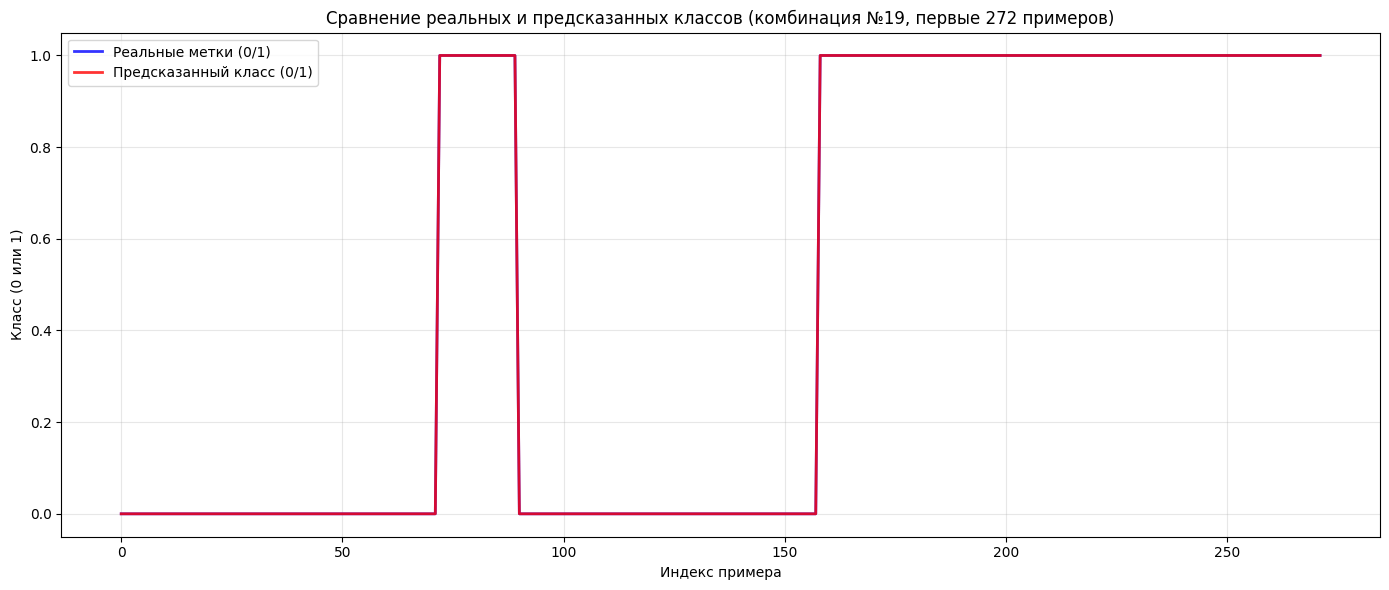

In [579]:
plot_model_by_combo_id(
    19,
    df_res_adasyn_3layer,
    X_adasyn,
    Y_adasyn,
    config['base']['random_state'],
    len(X_adasyn)
)

### <font color='#F5DEB3'>Итоги исследований

* **Лучший результат 1-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(50,), activation='relu', solver='lbfgs', max_iter=5000.
Accuracy = 0.8011 ± 0.0436, F1-score = 0.5470 ± 0.1046.

* **Лучший результат 1-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(50,), activation='tanh', solver='lbfgs', max_iter=1000.    
Accuracy = 0.7955 ± 0.0161, F1-score = 0.5201 ± 0.0415.

* **Лучший результат 1-го слоя (MinMaxScaled):**
Гиперпараметры - hidden_layer_sizes=(100,), activation='tanh', solver='lbfgs', max_iter=1000.   
Accuracy = 0.8409 ± 0.0321, F1-score = 0.6358 ± 0.0882.

* **Лучший результат 1-го слоя (SMOTE):**
Гиперпараметры - hidden_layer_sizes=(100,), activation='relu', solver='lbfgs', max_iter=10000.      
Accuracy = 0.9321 ± 0.0211, F1-score = 0.9362 ± 0.0193.

* **Лучший результат 1-го слоя (ADASYN):**
*Гиперпараметры - hidden_layer_sizes=(50,), activation='relu', solver='lbfgs', max_iter=1000.*    
*Accuracy = 0.9412 ± 0.0180, F1-score = 0.9425 ± 0.0172.*

---

* **Лучший результат 2-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(50, 20), activation='relu', solver='lbfgs', max_iter=1000.
Accuracy = 0.8068 ± 0.0197, F1-score = 0.5253 ± 0.0255.

* **Лучший результат 2-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=5000.     
Accuracy = 0.8352 ± 0.0373, F1-score = 0.5574 ± 0.0465.

* **Лучший результат 2-го слоя (MinMaxScaled):**
Гиперпараметры - hidden_layer_sizes=(20, 10), activation='relu', solver='lbfgs', max_iter=5000.     
Accuracy = 0.8011 ± 0.0098, F1-score = 0.5504 ± 0.1001.

* **Лучший результат 2-го слоя (SMOTE):**
Гиперпараметры - hidden_layer_sizes=(50, 20), activation='relu', solver='lbfgs', max_iter=10000.    
Accuracy = 0.9321 ± 0.0211, F1-score = 0.9364 ± 0.0185.

* **Лучший результат 2-го слоя (ADASYN):**
Гиперпараметры - hidden_layer_sizes=(20, 10), activation='relu', solver='lbfgs', max_iter=1000.     
Accuracy = 0.9007 ± 0.0366, F1-score = 0.9041 ± 0.0371.

---

* **Лучший результат 3-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(100, 50, 10), activation='tanh', solver='lbfgs', max_iter=5000.
Accuracy = 0.7500 ± 0.0359, F1-score = 0.4063 ± 0.0233.

* **Лучший результат 3-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(100, 100, 50), activation='relu', solver='adam', max_iter=5000.   
Accuracy = 0.8352 ± 0.0492, F1-score = 0.5858 ± 0.0430.

* **Лучший результат 3-го слоя (MinMaxScaled):**
Гиперпараметры - hidden_layer_sizes=(100, 100, 50), activation='tanh', solver='lbfgs', max_iter=5000.      
Accuracy = 0.8466 ± 0.0295, F1-score = 0.6399 ± 0.0670.

* **Лучший результат 3-го слоя (SMOTE):**
Гиперпараметры - hidden_layer_sizes=(100, 50, 50), activation='relu', solver='lbfgs', max_iter=1000.    
Accuracy = 0.9250 ± 0.0274, F1-score = 0.9292 ± 0.0254.

* **Лучший результат 3-го слоя (ADASYN):**
Гиперпараметры - hidden_layer_sizes=(100, 50, 50), activation='relu', solver='lbfgs', max_iter=1000.    
Accuracy = 0.9228 ± 0.0335, F1-score = 0.9237 ± 0.0348.

---

**Лучший результат: 1 слой с нормализацией и балансировкой ADASYN**.

### <font color='#F5DEB3'> Optuna

#### <font color='#F5DEB3'> 4.1 Балансировка класса с SMOTE

In [9]:
import optuna

cv_folds = config['MLP']['model_params']['cv_folds']
random_state = config['base']['random_state']
n_trials = 100 

def objective(trial):
    n_neurons = trial.suggest_int('n_neurons', 10, 1000)
    activation = trial.suggest_categorical('activation', ['relu'])
    solver = trial.suggest_categorical('solver', ['adam', 'lbfgs'])
    max_iter = trial.suggest_int('max_iter', 50, 1000, step=50)
    alpha = trial.suggest_float('alpha', 1e-3, 0.1, log=True)

    mlp = MLPClassifier(
        hidden_layer_sizes=(n_neurons,),
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        alpha=alpha,
        random_state=random_state
    )

    scores = cross_val_score(mlp, X_smote, Y_smote, cv=cv_folds, scoring='f1')
    return scores.mean()

study_1 = optuna.create_study(direction='maximize')
study_1.optimize(objective, n_trials=n_trials)

print("=== Однослойная сеть ===")
print("Лучший F1 (CV):", study_1.best_value)
print("Лучшие параметры:", study_1.best_params)

[I 2026-04-29 14:26:25,166] A new study created in memory with name: no-name-57a01275-2b78-4b0f-82e8-4ddc0cab91cd
[I 2026-04-29 14:26:30,312] Trial 0 finished with value: 0.9029793863127197 and parameters: {'n_neurons': 717, 'activation': 'relu', 'solver': 'adam', 'max_iter': 350, 'alpha': 0.0023726229479796674}. Best is trial 0 with value: 0.9029793863127197.
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2026-04-29 14:26:32,853] Trial 1 finished with value: 0.8759772741530001 and parameters: {'n_neurons': 196, 'activation': 'relu', 'solver': 'adam', 'max_iter': 600, 'alpha': 0.002420428118304325}. Best is trial 0 with value: 0.9029793863127197.
[I 2026-04-29 14:26:35,845] Trial 2 finished with value: 0.8706792142444182 and parameters: {'n_neurons': 402, 'activation': 'relu', 'solver': 'adam',

=== Однослойная сеть ===
Лучший F1 (CV): 0.9591704718417047
Лучшие параметры: {'n_neurons': 318, 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 650, 'alpha': 0.007653748815385286}


In [10]:
n_trials = 100

def objective(trial):
    n1 = trial.suggest_int('n_neurons_1', 10, 50)
    n2 = trial.suggest_int('n_neurons_2', 10, 50)
    activation = trial.suggest_categorical('activation', ['relu'])
    solver = trial.suggest_categorical('solver', ['adam', 'lbfgs'])
    max_iter = trial.suggest_int('max_iter', 50, 1000, step=50)
    alpha = trial.suggest_float('alpha', 1e-3, 0.1, log=True)

    mlp = MLPClassifier(
        hidden_layer_sizes=(n1, n2),
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        alpha=alpha,
        random_state=random_state
    )

    scores = cross_val_score(mlp, X_smote, Y_smote, cv=cv_folds, scoring='f1')
    return scores.mean()

study_2 = optuna.create_study(direction='maximize')
study_2.optimize(objective, n_trials=n_trials)

print("=== Двухслойная сеть ===")
print("Лучший F1 (CV):", study_2.best_value)
print("Лучшие параметры:", study_2.best_params)

[I 2026-04-29 14:41:58,051] A new study created in memory with name: no-name-39990678-b090-453f-9545-f9b14ba5caec
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300

=== Двухслойная сеть ===
Лучший F1 (CV): 0.9625937895255858
Лучшие параметры: {'n_neurons_1': 50, 'n_neurons_2': 48, 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 950, 'alpha': 0.055464486415708635}


In [11]:
n_trials = 100

def objective(trial):
    n1 = trial.suggest_int('n_neurons_1', 20, 40)
    n2 = trial.suggest_int('n_neurons_2', 10, 40)
    n3 = trial.suggest_int('n_neurons_3', 5, 30)
    activation = trial.suggest_categorical('activation', ['relu'])
    solver = trial.suggest_categorical('solver', ['lbfgs'])
    max_iter = trial.suggest_int('max_iter', 50, 1000, step=50)
    alpha = trial.suggest_float('alpha', 1e-3, 0.1, log=True)

    mlp = MLPClassifier(
        hidden_layer_sizes=(n1, n2, n3),
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        alpha=alpha,
        random_state=random_state
    )

    scores = cross_val_score(mlp, X_smote, Y_smote, cv=cv_folds, scoring='f1')
    return scores.mean()

study_3 = optuna.create_study(direction='maximize')
study_3.optimize(objective, n_trials=n_trials)

print("=== Трёхслойная сеть ===")
print("Лучший F1 (CV):", study_3.best_value)
print("Лучшие параметры:", study_3.best_params)

[I 2026-04-29 14:46:18,517] A new study created in memory with name: no-name-f2cffabf-3d1e-4a49-8653-160e3a5fb129
[I 2026-04-29 14:46:21,158] Trial 0 finished with value: 0.9261992255413308 and parameters: {'n_neurons_1': 21, 'n_neurons_2': 33, 'n_neurons_3': 22, 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 750, 'alpha': 0.0035033678395124065}. Best is trial 0 with value: 0.9261992255413308.
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ML_Labs\LB3_ML_Yakushev\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: Co

=== Трёхслойная сеть ===
Лучший F1 (CV): 0.959354248614812
Лучшие параметры: {'n_neurons_1': 30, 'n_neurons_2': 13, 'n_neurons_3': 16, 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 900, 'alpha': 0.04907716056816496}


In [12]:
def plot_train_test_predictions_cv(
    X, y,                     # полные данные (признаки и метки)
    parameters,               # словарь гиперпараметров для MLPClassifier
    cv_folds=4,               # число фолдов
    title_prefix="",
    n_show=None,
    output_path=None,
    dpi=600
):
    # 1. Кросс-валидация для оценки качества

    mlp_cv = MLPClassifier(**parameters, random_state=42)

    scores_acc = cross_val_score(mlp_cv, X, y, cv=cv_folds, scoring='accuracy')
    scores_f1 = cross_val_score(mlp_cv, X, y, cv=cv_folds, scoring='f1')

    acc_mean, acc_std = scores_acc.mean(), scores_acc.std()
    f1_mean, f1_std = scores_f1.mean(), scores_f1.std()

    print(f"\n{title_prefix} (кросс-валидация, {cv_folds} фолдов)")
    print(f"Accuracy : {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"F1-score : {f1_mean:.4f} ± {f1_std:.4f}")

    # 2. Обучение на всех данных для визуализации
    mlp_full = MLPClassifier(**parameters, random_state=42)
    mlp_full.fit(X, y)
    y_pred = mlp_full.predict(X)

    # 3. Метрики на полной выборке (для справки)
    acc_full = accuracy_score(y, y_pred)
    f1_full = f1_score(y, y_pred, average='binary')
    print(f"На полной выборке: Accuracy = {acc_full:.4f}, F1 = {f1_full:.4f}")

    # 4. Визуализация
    if n_show is None:
        n_show = len(y)
    else:
        n_show = min(n_show, len(y))

    indices = np.arange(n_show)

    plt.figure(figsize=(14, 6))
    plt.plot(indices, y[:n_show], label='Реальные метки',
             color='blue', linewidth=2, alpha=0.8)
    plt.plot(indices, y_pred[:n_show], label='Предсказанные',
             color='red', linewidth=2, alpha=0.8)
    plt.xlabel('Индекс примера')
    plt.ylabel('Класс')
    plt.title(f'{title_prefix} (CV Acc={acc_mean:.3f}±{acc_std:.3f}, F1={f1_mean:.3f}±{f1_std:.3f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=dpi, bbox_inches='tight')
    plt.show()

# ------------------------------------------------------------
# Основной блок: подготовка данных и визуализация

# Разделяем данные (80% обучение, 20% проверка) стратифицированно
X_train, X_test, Y_train, Y_test = train_test_split(
    X_adasyn, Y_adasyn,
    test_size=0.2,
    random_state=42,
    stratify=Y_adasyn
)

# Параметры трёх лучших моделей (из результатов Optuna)
best_params_1 = study_1.best_params   # однослойная
best_params_2 = study_2.best_params   # двухслойная
best_params_3 = study_3.best_params   # трёхслойная

# Приводим параметры к нужному формату для MLPClassifier
def prepare_params(params, n_layers):
    """Извлекает параметры из словаря Optuna и формирует hidden_layer_sizes."""
    model_params = {
        'activation': params['activation'],
        'solver': params['solver'],
        'max_iter': params['max_iter'],
        'alpha': params['alpha'],
    }
    if n_layers == 1:
        model_params['hidden_layer_sizes'] = (params['n_neurons'],)
    elif n_layers == 2:
        model_params['hidden_layer_sizes'] = (params['n_neurons_1'], params['n_neurons_2'])
    elif n_layers == 3:
        model_params['hidden_layer_sizes'] = (params['n_neurons_1'], params['n_neurons_2'], params['n_neurons_3'])
    return model_params

params1 = prepare_params(best_params_1, 1)
params2 = prepare_params(best_params_2, 2)
params3 = prepare_params(best_params_3, 3)

# Строим графики для каждой модели
plot_train_test_predictions_cv(
    X_adasyn, Y_adasyn,
    params1,
    title_prefix="Однослойная сеть (лучшие параметры)"
)

plot_train_test_predictions_cv(
    X_adasyn, Y_adasyn,
    params2,
    title_prefix="Двухслойная сеть (лучшие параметры)"
)

plot_train_test_predictions_cv(
    X_adasyn, Y_adasyn,
    params3,
    title_prefix="Трёхслойная сеть (лучшие параметры)"
)

NameError: name 'X_adasyn' is not defined